# 06. Двухстадийная модель прогнозирования GMV

Цель ноутбука — построить воспроизводимый двухстадийный пайплайн для прогноза суммарного GMV пользователя за период с 14 февраля по 15 марта 2026 года.

Модель состоит из двух частей:

1. классификатор оценивает вероятность положительного GMV в следующие 30 дней;
2. регрессор оценивает размер GMV при условии, что он положительный.

Гиперпараметры двух стадий настраиваются в отдельных Optuna-study. Итоговая связка выбирается по end-to-end RMSLE на последовательных временных фолдах.

> Кодовые ячейки добавляются по одной после обсуждения соответствующего блока в чате.

## 1. Формализация задачи и варианты объединения стадий

На этом шаге фиксируются обозначения и формулы, которые будут использоваться далее:

- `p_nonzero = P(target_gmv_30d > 0 | X)` — прогноз классификатора;
- `pred_log_positive = E[log1p(target_gmv_30d) | target_gmv_30d > 0, X]` — прогноз регрессора;
- RMSLE-согласованный прогноз: `expm1(p_nonzero * pred_log_positive)`;
- прогноз ожидаемого GMV в исходном масштабе: `p_nonzero * expm1(pred_log_positive)`;
- пороговый вариант используется только как challenger и для диагностики recall/F2.

Основная метрика всего пайплайна — RMSLE. Recall и F2 с приоритетом recall используются для анализа первой стадии, но не заменяют финальную метрику.

## 2. Окружение, библиотеки и воспроизводимость

Будущий кодовый блок должен:

- импортировать `pyarrow`, `numpy`, `pandas`, `lightgbm`, `optuna`, `shap`, `scikit-learn` и `matplotlib`;
- вывести версии ключевых библиотек;
- зафиксировать `RANDOM_STATE = 42`;
- ограничить Optuna одним последовательным trial и передать CPU-параллелизм LightGBM;
- определить пути к данным и артефактам;
- собрать все изменяемые параметры эксперимента в одном конфигурационном блоке.

Предварительная конфигурация: `OPTUNA_N_JOBS = 1`, `LIGHTGBM_NUM_THREADS = 10`.

In [2]:
import os
import random
import sys
from datetime import date
from importlib.metadata import version as package_version
from pathlib import Path

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pyarrow
import pyarrow.dataset as ds
import shap
import sklearn


# Воспроизводимость
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Ресурсы
CPU_COUNT = os.cpu_count() or 1
LIGHTGBM_NUM_THREADS = max(1, min(10, CPU_COUNT - 2))
OPTUNA_N_JOBS = 1


# Бюджет обучения
N_TRIALS_CLASSIFIER = 40
N_TRIALS_REGRESSOR = 40
MAX_BOOST_ROUNDS = 5_000
EARLY_STOPPING_ROUNDS = 150
SHAP_SAMPLE_SIZE = 20_000


# Временная схема
TUNING_FOLDS = (
    {
        "name": "fold_1",
        "train_end": date(2025, 9, 16),
        "valid_date": date(2025, 10, 16),
    },
    {
        "name": "fold_2",
        "train_end": date(2025, 10, 16),
        "valid_date": date(2025, 11, 15),
    },
    {
        "name": "fold_3",
        "train_end": date(2025, 11, 15),
        "valid_date": date(2025, 12, 15),
    },
)

HOLDOUT_DATE = date(2026, 1, 14)
INFERENCE_DATE = date(2026, 2, 13)
FORECAST_START = date(2026, 2, 14)
FORECAST_END = date(2026, 3, 15)


def find_project_root(start: Path) -> Path:
    """Ищет корень проекта по расположению Prepared_data.parquet."""
    for directory in (start, *start.parents):
        if (directory / "data" / "Prepared_data.parquet").is_file():
            return directory

    raise FileNotFoundError(
        "Не найден data/Prepared_data.parquet. "
        "Запустите ноутбук из папки проекта или её подпапки."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "Prepared_data.parquet"
ARTIFACT_DIR = PROJECT_ROOT / "data" / "two_stage_artifacts"


# Исполняемые проверки конфигурации
assert DATA_PATH.is_file()
assert OPTUNA_N_JOBS == 1
assert 1 <= LIGHTGBM_NUM_THREADS <= CPU_COUNT
assert len({fold["valid_date"] for fold in TUNING_FOLDS}) == len(
    TUNING_FOLDS
)
assert all(
    fold["train_end"] < fold["valid_date"] < HOLDOUT_DATE
    for fold in TUNING_FOLDS
)
assert HOLDOUT_DATE < INFERENCE_DATE < FORECAST_START <= FORECAST_END
assert (FORECAST_END - FORECAST_START).days + 1 == 30


# Единое оформление будущих графиков
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "PyArrow": package_version("pyarrow"),
        "LightGBM": package_version("lightgbm"),
        "Optuna": package_version("optuna"),
        "SHAP": package_version("shap"),
        "scikit-learn": package_version("scikit-learn"),
        "Matplotlib": package_version("matplotlib"),
    },
    name="version",
).to_frame()

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset:      {DATA_PATH}")
print(f"CPU threads:  {LIGHTGBM_NUM_THREADS} / {CPU_COUNT}")
print(f"Artifacts:    {ARTIFACT_DIR}")

versions

Project root: <PROJECT_ROOT>
Dataset:      <PROJECT_ROOT>\data\Prepared_data.parquet
CPU threads:  10 / 12
Artifacts:    <PROJECT_ROOT>\data\two_stage_artifacts


,version
Python,3.14.0
NumPy,2.3.3
pandas,2.3.3
PyArrow,25.0.1
LightGBM,4.6.0
Optuna,4.8.0
SHAP,0.52.0
scikit-learn,1.8.0
Matplotlib,3.10.7


## 3. Чтение `Prepared_data.parquet` через PyArrow

Данные читаются с predicate pushdown по `cutoff_date` и только с необходимыми колонками. Во время настройки моделей `user_id` не загружается.

Будущий кодовый блок должен вернуть:

- матрицу из 91 модельного признака;
- массив дат отсечки;
- `target_nonzero`;
- `target_gmv_30d`;
- отдельное описание inference-среза `2026-02-13`.

Признаки хранятся как `float32`, денежный target и его логарифм — как `float64`, бинарный target — как `int8`.

In [3]:
import pyarrow.parquet as pq


SERVICE_COLUMNS = ("user_id", "cutoff_date")
TARGET_COLUMNS = ("target_gmv_30d", "target_nonzero")
EXPECTED_FEATURE_COUNT = 91

EXPECTED_CUTOFFS = {
    date(2025, 4, 19),
    date(2025, 5, 19),
    date(2025, 6, 18),
    date(2025, 7, 18),
    date(2025, 8, 17),
    date(2025, 9, 16),
    date(2025, 10, 16),
    date(2025, 11, 15),
    date(2025, 12, 15),
    HOLDOUT_DATE,
    INFERENCE_DATE,
}


# PyArrow Dataset нужен для фильтрации по cutoff_date без чтения всего файла.
prepared_dataset = ds.dataset(
    DATA_PATH,
    format="parquet",
)

parquet_file = pq.ParquetFile(DATA_PATH)
schema = prepared_dataset.schema

missing_columns = (
    set(SERVICE_COLUMNS)
    | set(TARGET_COLUMNS)
) - set(schema.names)

assert not missing_columns, (
    f"В датасете отсутствуют колонки: {sorted(missing_columns)}"
)


FEATURE_COLUMNS = tuple(
    column
    for column in schema.names
    if column not in SERVICE_COLUMNS + TARGET_COLUMNS
)

MODEL_COLUMNS = (
    *FEATURE_COLUMNS,
    *TARGET_COLUMNS,
)


assert len(FEATURE_COLUMNS) == EXPECTED_FEATURE_COUNT, (
    f"Ожидалось {EXPECTED_FEATURE_COUNT} признаков, "
    f"получено {len(FEATURE_COLUMNS)}"
)

assert len(schema.names) == (
    len(SERVICE_COLUMNS)
    + len(FEATURE_COLUMNS)
    + len(TARGET_COLUMNS)
)


# Для первичной проверки читаем только cutoff и бинарный target.
# Это существенно дешевле загрузки 91 признака.
cutoff_summary = (
    prepared_dataset
    .to_table(
        columns=[
            "cutoff_date",
            "target_nonzero",
        ]
    )
    .group_by("cutoff_date")
    .aggregate(
        [
            ("cutoff_date", "count"),
            ("target_nonzero", "count"),
            ("target_nonzero", "mean"),
        ]
    )
    .to_pandas()
    .rename(
        columns={
            "cutoff_date_count": "rows",
            "target_nonzero_count": "labeled_rows",
            "target_nonzero_mean": "positive_share",
        }
    )
    .sort_values("cutoff_date")
    .reset_index(drop=True)
)

cutoff_summary["cutoff_date"] = pd.to_datetime(
    cutoff_summary["cutoff_date"]
).dt.date

observed_cutoffs = set(cutoff_summary["cutoff_date"])

assert observed_cutoffs == EXPECTED_CUTOFFS, (
    f"Не совпали даты snapshot. "
    f"Отсутствуют: {sorted(EXPECTED_CUTOFFS - observed_cutoffs)}; "
    f"лишние: {sorted(observed_cutoffs - EXPECTED_CUTOFFS)}"
)

assert cutoff_summary["rows"].sum() == parquet_file.metadata.num_rows
assert cutoff_summary["labeled_rows"].iloc[:-1].eq(
    cutoff_summary["rows"].iloc[:-1]
).all()

inference_row = cutoff_summary.loc[
    cutoff_summary["cutoff_date"].eq(INFERENCE_DATE)
].iloc[0]

assert inference_row["labeled_rows"] == 0
assert pd.isna(inference_row["positive_share"])


schema_summary = pd.DataFrame(
    {
        "column": schema.names,
        "arrow_type": [str(field.type) for field in schema],
        "role": [
            (
                "service"
                if column in SERVICE_COLUMNS
                else "target"
                if column in TARGET_COLUMNS
                else "feature"
            )
            for column in schema.names
        ],
    }
)

dataset_summary = pd.Series(
    {
        "file_size_gb": DATA_PATH.stat().st_size / 1024**3,
        "rows": parquet_file.metadata.num_rows,
        "row_groups": parquet_file.metadata.num_row_groups,
        "total_columns": len(schema.names),
        "feature_columns": len(FEATURE_COLUMNS),
        "labeled_rows": cutoff_summary["labeled_rows"].sum(),
        "inference_rows": inference_row["rows"],
    },
    name="value",
).to_frame()


display(dataset_summary)
display(cutoff_summary)
display(schema_summary.groupby(["role", "arrow_type"]).size().to_frame("columns"))

,value
file_size_gb,3.397297e-01
rows,2.597330e+06
row_groups,4.400000e+01
total_columns,9.500000e+01
feature_columns,9.100000e+01
labeled_rows,2.347330e+06
inference_rows,2.500000e+05


,cutoff_date,rows,labeled_rows,positive_share
0,2025-04-19,216457,216457,0.472080
1,2025-05-19,221154,221154,0.482533
2,2025-06-18,225245,225245,0.494204
3,2025-07-18,229146,229146,0.511032
4,2025-08-17,232977,232977,0.528387
5,2025-09-16,236668,236668,0.536258
6,2025-10-16,240700,240700,0.545858
7,2025-11-15,244983,244983,0.569435
8,2025-12-15,250000,250000,0.563080
9,2026-01-14,250000,250000,0.540660


columns
role    arrow_type          
feature float             50
        int32             36
        int8               5
service date32[day]        1
        int64              1
target  double             1
        int8               1

In [4]:
import gc


LABELED_FILTER = ds.field("cutoff_date") <= HOLDOUT_DATE

expected_labeled_rows = int(
    cutoff_summary.loc[
        cutoff_summary["cutoff_date"] <= HOLDOUT_DATE,
        "rows",
    ].sum()
)


# Сначала читаем небольшой блок с датами и целями.
target_table = prepared_dataset.to_table(
    columns=[
        "cutoff_date",
        "target_nonzero",
        "target_gmv_30d",
    ],
    filter=LABELED_FILTER,
)

assert target_table.num_rows == expected_labeled_rows

cutoff_dates = pd.to_datetime(
    target_table["cutoff_date"].to_pandas(
        date_as_object=False
    )
)

y_nonzero = (
    target_table["target_nonzero"]
    .to_numpy(zero_copy_only=False)
    .astype(np.int8, copy=False)
)

y_gmv = (
    target_table["target_gmv_30d"]
    .to_numpy(zero_copy_only=False)
    .astype(np.float64, copy=False)
)

del target_table
gc.collect()


# Матрица признаков читается отдельно:
# так пиковое потребление памяти ниже, чем при создании общего DataFrame.
feature_table = prepared_dataset.to_table(
    columns=list(FEATURE_COLUMNS),
    filter=LABELED_FILTER,
)

assert feature_table.num_rows == expected_labeled_rows

X = feature_table.to_pandas(
    split_blocks=True,
)

del feature_table
gc.collect()


# Проверка формы, порядка и типов.
assert X.shape == (
    expected_labeled_rows,
    EXPECTED_FEATURE_COUNT,
)

assert tuple(X.columns) == FEATURE_COLUMNS
assert len(cutoff_dates) == len(X)
assert len(y_nonzero) == len(X)
assert len(y_gmv) == len(X)

assert all(dtype.kind in "fiu" for dtype in X.dtypes)
assert not X.dtypes.astype(str).eq("float64").any()

assert np.isfinite(y_gmv).all()
assert (y_gmv >= 0).all()
assert np.isin(y_nonzero, [0, 1]).all()

assert np.array_equal(
    y_nonzero,
    (y_gmv > 0).astype(np.int8),
)


loaded_data_summary = pd.Series(
    {
        "rows": len(X),
        "features": X.shape[1],
        "X_memory_gb": (
            X.memory_usage(index=True, deep=True).sum()
            / 1024**3
        ),
        "targets_memory_mb": (
            y_nonzero.nbytes + y_gmv.nbytes
        ) / 1024**2,
        "cutoff_min": cutoff_dates.min().date(),
        "cutoff_max": cutoff_dates.max().date(),
        "positive_share": y_nonzero.mean(),
        "positive_gmv_median": np.median(
            y_gmv[y_nonzero == 1]
        ),
    },
    name="value",
).to_frame()

feature_dtype_summary = (
    X.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("dtype")
    .to_frame("columns")
)


display(loaded_data_summary)
display(feature_dtype_summary)

,value
rows,2347330
features,91
X_memory_gb,0.762956
targets_memory_mb,20.147295
cutoff_min,2025-04-19
cutoff_max,2026-01-14
positive_share,0.525771
positive_gmv_median,69.355967


,columns
dtype,
float32,50
int32,36
int8,5


## 4. Проверка схемы и качества модельной таблицы

Перед обучением проверяются:

- наличие всех служебных, целевых и модельных колонок;
- уникальность `user_id × cutoff_date` в исходной таблице;
- отсутствие отрицательного GMV;
- согласованность `target_nonzero` и `target_gmv_30d`;
- отсутствие бесконечностей в признаках;
- допустимые даты и отсутствие target у inference-среза;
- доля пропусков и потребление памяти.

`NaN` сохраняются: LightGBM обрабатывает их нативно. Масштабирование и заполнение медианой не применяются.

,value
cutoff_order_violations,0
user_order_violations,0
duplicate_user_cutoff,0
features_with_missing,26
features_with_infinity,0
constant_features,1
binary_features,5


,zero_count,one_count,one_share
feature,,,
never_purchased,1858802,488528,0.208121
customer_age_left_censored,1912170,435160,0.185385
no_recent_engagement,2290719,56611,0.024117
never_searched,2329222,18108,0.007714
cart_purchase_exceeds_cart,2347330,0,0.000000


,dtype,missing_count,missing_share,min,max
feature,,,,,
search_gmv_share_30d,float32,1140080,0.485692,0.000000,1.000000
purchase_velocity_7d_vs_30d,float32,1140080,0.485692,0.000000,4.285714
category_cart_to_purchase_rate,float32,1036941,0.441753,0.000000,1.000000
median_purchase_gap_days,float32,719832,0.306660,1.000000,377.000000
recency_ratio,float32,719832,0.306660,0.000000,377.000000
search_gmv_share_90d,float32,711793,0.303235,0.000000,1.000000
cart_velocity_7d_vs_30d,float32,613990,0.261570,0.000000,4.285714
search_to_purchase_freq,float32,488528,0.208121,0.000000,15688.000000
gmv_per_item,float32,488528,0.208121,0.030756,73830.296875


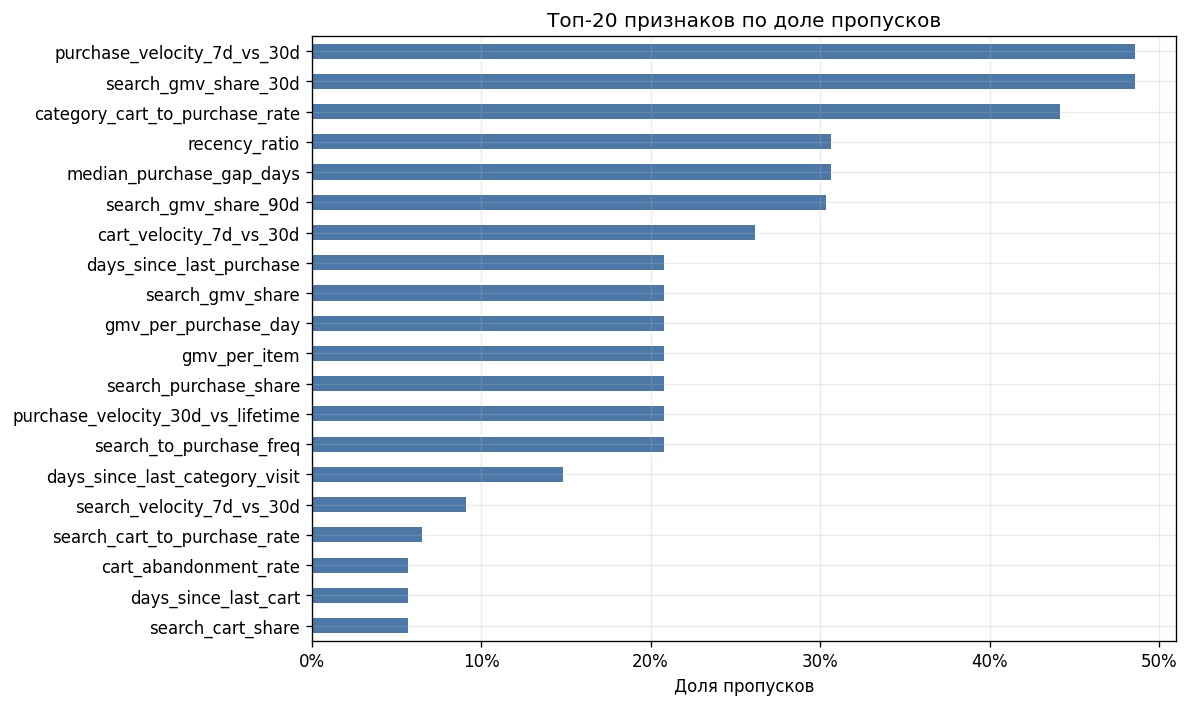

In [7]:
# Проверка физического порядка и уникальности user_id × cutoff_date.
# Читаем только две компактные служебные колонки.
service_table = prepared_dataset.to_table(
    columns=[
        "cutoff_date",
        "user_id",
    ]
)

key_cutoffs = service_table[
    "cutoff_date"
].to_numpy(zero_copy_only=False)

key_user_ids = service_table[
    "user_id"
].to_numpy(zero_copy_only=False)

assert len(key_cutoffs) == parquet_file.metadata.num_rows
assert len(key_user_ids) == parquet_file.metadata.num_rows

del service_table
gc.collect()


same_cutoff = key_cutoffs[1:] == key_cutoffs[:-1]

cutoff_order_violations = int(
    np.count_nonzero(
        key_cutoffs[1:] < key_cutoffs[:-1]
    )
)

user_order_violations = int(
    np.count_nonzero(
        same_cutoff
        & (key_user_ids[1:] < key_user_ids[:-1])
    )
)

duplicate_keys = int(
    np.count_nonzero(
        same_cutoff
        & (key_user_ids[1:] == key_user_ids[:-1])
    )
)

assert cutoff_order_violations == 0
assert user_order_violations == 0
assert duplicate_keys == 0

del key_cutoffs, key_user_ids, same_cutoff
gc.collect()


# Проверяем каждый признак отдельно, не создавая
# матрицу boolean размером со весь X.
quality_records = []

for column in FEATURE_COLUMNS:
    values = X[column].to_numpy(copy=False)
    is_float = np.issubdtype(
        values.dtype,
        np.floating,
    )

    if is_float:
        missing_count = int(
            np.count_nonzero(np.isnan(values))
        )
        infinite_count = int(
            np.count_nonzero(np.isinf(values))
        )
    else:
        missing_count = 0
        infinite_count = 0

    defined_count = len(values) - missing_count

    quality_records.append(
        {
            "feature": column,
            "dtype": str(values.dtype),
            "missing_count": missing_count,
            "missing_share": missing_count / len(values),
            "infinite_count": infinite_count,
            "min": (
                float(np.nanmin(values))
                if defined_count
                else np.nan
            ),
            "max": (
                float(np.nanmax(values))
                if defined_count
                else np.nan
            ),
        }
    )

feature_quality = (
    pd.DataFrame(quality_records)
    .set_index("feature")
)

feature_quality["constant"] = (
    feature_quality["min"]
    == feature_quality["max"]
)


assert feature_quality["infinite_count"].sum() == 0
assert feature_quality["missing_count"].lt(len(X)).all()


# Все int8-признаки были заявлены как бинарные флаги.
BINARY_FEATURES = tuple(
    X.select_dtypes(include=["int8"]).columns
)

binary_records = []

for column in BINARY_FEATURES:
    values = X[column].to_numpy(copy=False)

    assert np.isin(values, [0, 1]).all(), (
        f"{column} содержит значения вне {{0, 1}}"
    )

    binary_records.append(
        {
            "feature": column,
            "zero_count": int(
                np.count_nonzero(values == 0)
            ),
            "one_count": int(
                np.count_nonzero(values == 1)
            ),
            "one_share": float(values.mean()),
        }
    )

binary_summary = (
    pd.DataFrame(binary_records)
    .set_index("feature")
    .sort_values("one_share", ascending=False)
)


# Сверяем число строк по календарным датам,
# не завися от datetime64[ms] / datetime64[ns].
observed_cutoff_counts = {
    timestamp.date(): int(count)
    for timestamp, count in (
        cutoff_dates
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_cutoff_counts = {
    row.cutoff_date: int(row.rows)
    for row in cutoff_summary.itertuples()
    if row.cutoff_date <= HOLDOUT_DATE
}

assert observed_cutoff_counts == expected_cutoff_counts, (
    "Не совпало число строк по cutoff_date.\n"
    f"Фактические значения: {observed_cutoff_counts}\n"
    f"Ожидаемые значения: {expected_cutoff_counts}"
)


validation_summary = pd.Series(
    {
        "cutoff_order_violations": cutoff_order_violations,
        "user_order_violations": user_order_violations,
        "duplicate_user_cutoff": duplicate_keys,
        "features_with_missing": int(
            feature_quality["missing_count"].gt(0).sum()
        ),
        "features_with_infinity": int(
            feature_quality["infinite_count"].gt(0).sum()
        ),
        "constant_features": int(
            feature_quality["constant"].sum()
        ),
        "binary_features": len(BINARY_FEATURES),
    },
    name="value",
).to_frame()

top_missing_features = (
    feature_quality.loc[
        feature_quality["missing_count"] > 0,
        [
            "dtype",
            "missing_count",
            "missing_share",
            "min",
            "max",
        ],
    ]
    .sort_values("missing_share", ascending=False)
)


display(validation_summary)
display(binary_summary)
display(top_missing_features.head(20))


if not top_missing_features.empty:
    plot_data = (
        top_missing_features["missing_share"]
        .head(20)
        .sort_values()
    )

    ax = plot_data.plot.barh(
        color="#4C78A8",
        figsize=(10, 6),
    )
    ax.set_title("Топ-20 признаков по доле пропусков")
    ax.set_xlabel("Доля пропусков")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.PercentFormatter(1)
    )
    plt.tight_layout()
    plt.show()

In [8]:
DROPPED_FEATURES = (
    "cart_purchase_exceeds_cart",
)

detected_constant_features = tuple(
    feature_quality.index[
        feature_quality["constant"]
    ]
)

# Защита от неожиданного автоматического удаления
# других признаков при изменении датасета.
assert set(detected_constant_features) == set(
    DROPPED_FEATURES
), (
    f"Ожидались константы {DROPPED_FEATURES}, "
    f"обнаружены {detected_constant_features}"
)

assert all(
    feature in X.columns
    for feature in DROPPED_FEATURES
)

X.drop(
    columns=list(DROPPED_FEATURES),
    inplace=True,
)

MODEL_FEATURE_COLUMNS = tuple(X.columns)

assert len(MODEL_FEATURE_COLUMNS) == 90
assert not set(DROPPED_FEATURES) & set(
    MODEL_FEATURE_COLUMNS
)

model_matrix_summary = pd.Series(
    {
        "raw_features": len(FEATURE_COLUMNS),
        "dropped_features": len(DROPPED_FEATURES),
        "model_features": len(MODEL_FEATURE_COLUMNS),
        "X_memory_gb": (
            X.memory_usage(index=True, deep=True).sum()
            / 1024**3
        ),
    },
    name="value",
).to_frame()

display(model_matrix_summary)

,value
raw_features,91.00000
dropped_features,1.00000
model_features,90.00000
X_memory_gb,0.76077


## 5. Ручные expanding-window фолды

Фолды задаются явно по полным значениям `cutoff_date`:

| Fold | Train | Validation |
|---|---|---|
| 1 | cutoff ≤ 2025-09-16 | 2025-10-16 |
| 2 | cutoff ≤ 2025-10-16 | 2025-11-15 |
| 3 | cutoff ≤ 2025-11-15 | 2025-12-15 |

`2026-01-14` сохраняется как закрытый holdout, `2026-02-13` — как inference.

Будущий блок создаёт индексы строк и проверяет, что максимальная train-дата строго меньше validation-даты, фолды не пересекаются, а holdout не попал в Optuna. Здесь же строится timeline разбиений и таблица размера/доли положительного класса по cutoff.

,split,purpose,train_start,train_end,valid_date,train_rows,valid_rows,train_positive_share,valid_positive_share
0,fold_1,tuning,2025-04-19,2025-09-16,2025-10-16,1361647,240700,0.504781,0.545858
1,fold_2,tuning,2025-04-19,2025-10-16,2025-11-15,1602347,244983,0.510952,0.569435
2,fold_3,tuning,2025-04-19,2025-11-15,2025-12-15,1847330,250000,0.518708,0.563080
3,holdout,final evaluation,2025-04-19,2025-12-15,2026-01-14,2097330,250000,0.523997,0.540660


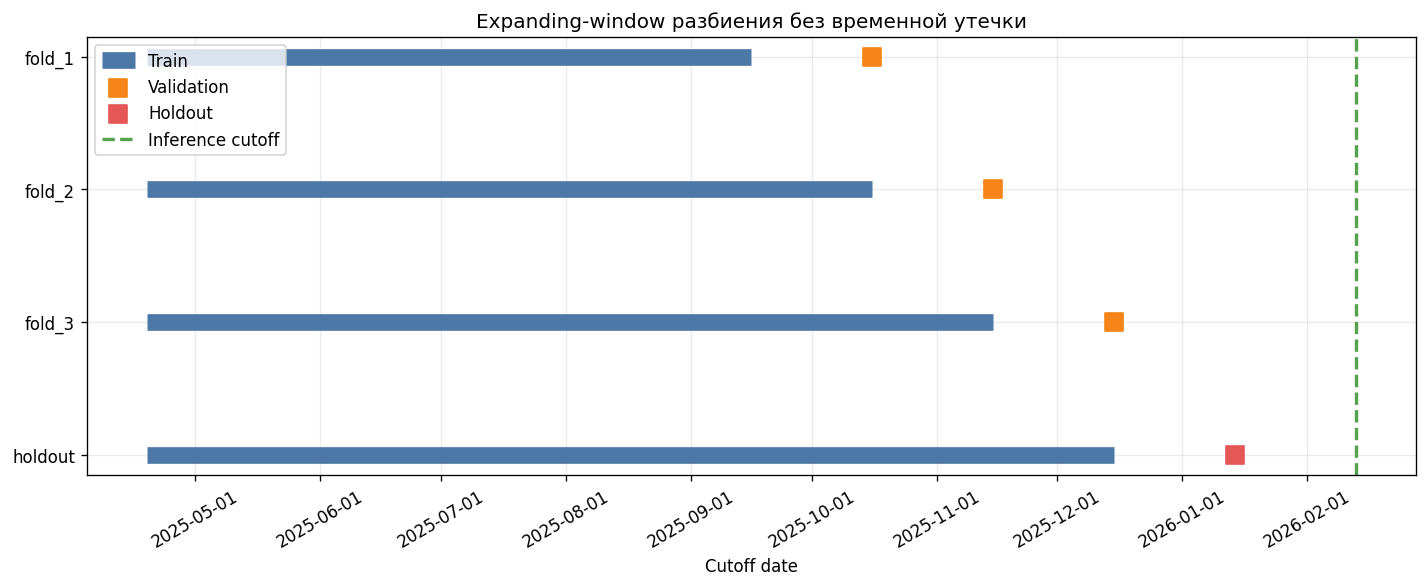

In [10]:
assert cutoff_dates.is_monotonic_increasing
assert len(cutoff_dates) == len(X)


TUNING_SPLITS = {}
split_records = []

for fold_spec in TUNING_FOLDS:
    train_end = pd.Timestamp(
        fold_spec["train_end"]
    )
    valid_date = pd.Timestamp(
        fold_spec["valid_date"]
    )

    train_stop = int(
        cutoff_dates.searchsorted(
            train_end,
            side="right",
        )
    )
    valid_start = int(
        cutoff_dates.searchsorted(
            valid_date,
            side="left",
        )
    )
    valid_stop = int(
        cutoff_dates.searchsorted(
            valid_date,
            side="right",
        )
    )

    train_slice = slice(0, train_stop)
    valid_slice = slice(valid_start, valid_stop)

    train_dates = cutoff_dates.iloc[train_slice]
    valid_dates = cutoff_dates.iloc[valid_slice]

    # Проверки отсутствия временной утечки.
    assert train_slice.stop <= valid_slice.start
    assert len(train_dates) > 0
    assert len(valid_dates) > 0

    assert train_dates.max() < valid_dates.min()
    assert train_dates.max().date() == fold_spec["train_end"]

    assert valid_dates.nunique() == 1
    assert valid_dates.iloc[0].date() == fold_spec["valid_date"]

    assert not train_dates.eq(
        pd.Timestamp(HOLDOUT_DATE)
    ).any()

    assert not valid_dates.eq(
        pd.Timestamp(HOLDOUT_DATE)
    ).any()

    TUNING_SPLITS[fold_spec["name"]] = {
        "train": train_slice,
        "valid": valid_slice,
        "train_end": fold_spec["train_end"],
        "valid_date": fold_spec["valid_date"],
    }

    split_records.append(
        {
            "split": fold_spec["name"],
            "purpose": "tuning",
            "train_start": train_dates.min().date(),
            "train_end": train_dates.max().date(),
            "valid_date": valid_dates.iloc[0].date(),
            "train_rows": len(train_dates),
            "valid_rows": len(valid_dates),
            "train_positive_share": float(
                y_nonzero[train_slice].mean()
            ),
            "valid_positive_share": float(
                y_nonzero[valid_slice].mean()
            ),
        }
    )


# Закрытый holdout: обучение по декабрь включительно,
# проверка только на январском snapshot.
holdout_timestamp = pd.Timestamp(HOLDOUT_DATE)

holdout_start = int(
    cutoff_dates.searchsorted(
        holdout_timestamp,
        side="left",
    )
)
holdout_stop = int(
    cutoff_dates.searchsorted(
        holdout_timestamp,
        side="right",
    )
)

HOLDOUT_SPLIT = {
    "train": slice(0, holdout_start),
    "valid": slice(holdout_start, holdout_stop),
    "valid_date": HOLDOUT_DATE,
}

holdout_train_dates = cutoff_dates.iloc[
    HOLDOUT_SPLIT["train"]
]
holdout_valid_dates = cutoff_dates.iloc[
    HOLDOUT_SPLIT["valid"]
]

assert holdout_start < holdout_stop
assert holdout_stop == len(X)
assert holdout_train_dates.max() < holdout_valid_dates.min()
assert holdout_valid_dates.nunique() == 1
assert holdout_valid_dates.iloc[0].date() == HOLDOUT_DATE

split_records.append(
    {
        "split": "holdout",
        "purpose": "final evaluation",
        "train_start": holdout_train_dates.min().date(),
        "train_end": holdout_train_dates.max().date(),
        "valid_date": HOLDOUT_DATE,
        "train_rows": len(holdout_train_dates),
        "valid_rows": len(holdout_valid_dates),
        "train_positive_share": float(
            y_nonzero[HOLDOUT_SPLIT["train"]].mean()
        ),
        "valid_positive_share": float(
            y_nonzero[HOLDOUT_SPLIT["valid"]].mean()
        ),
    }
)


split_summary = pd.DataFrame(split_records)

tuning_summary = split_summary.loc[
    split_summary["purpose"].eq("tuning")
]

assert tuning_summary[
    "train_rows"
].is_monotonic_increasing

assert tuning_summary[
    "valid_date"
].is_monotonic_increasing

assert len(TUNING_SPLITS) == 3


display(split_summary)


# Временная диаграмма разбиений.
fig, ax = plt.subplots(figsize=(12, 5))

for row_number, row in split_summary.iterrows():
    is_holdout = row["purpose"] == "final evaluation"

    ax.hlines(
        y=row_number,
        xmin=pd.Timestamp(row["train_start"]),
        xmax=pd.Timestamp(row["train_end"]),
        linewidth=10,
        color="#4C78A8",
        label="Train" if row_number == 0 else None,
    )

    ax.scatter(
        pd.Timestamp(row["valid_date"]),
        row_number,
        s=120,
        marker="s",
        color="#E45756" if is_holdout else "#F58518",
        label=(
            "Holdout"
            if is_holdout
            else "Validation"
            if row_number == 0
            else None
        ),
        zorder=3,
    )

ax.axvline(
    pd.Timestamp(INFERENCE_DATE),
    color="#54A24B",
    linestyle="--",
    linewidth=2,
    label="Inference cutoff",
)

ax.set_yticks(
    range(len(split_summary)),
    split_summary["split"],
)
ax.invert_yaxis()
ax.set_title(
    "Expanding-window разбиения без временной утечки"
)
ax.set_xlabel("Cutoff date")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    matplotlib.dates.DateFormatter("%Y-%m-%d")
)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Метрики и общие функции оценки

Будущий кодовый блок определяет единый набор метрик:

- классификация: Average Precision, logloss, Brier score, precision, recall и F2;
- положительная регрессия: RMSE и MAE в `log1p`-пространстве;
- весь пайплайн: RMSLE, отношение `sum(prediction) / sum(actual)` и log-bias;
- метрики по отдельным cutoff и агрегированное среднее/стандартное отклонение по фолдам.

Все последующие блоки должны использовать эти функции, чтобы определения метрик не расходились.

In [12]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    fbeta_score,
    log_loss,
    precision_score,
    recall_score,
)


def rmsle(actual, prediction):
    """Root Mean Squared Logarithmic Error."""
    actual = np.asarray(actual, dtype=np.float64)
    prediction = np.asarray(prediction, dtype=np.float64)

    if actual.shape != prediction.shape:
        raise ValueError(
            "actual и prediction должны иметь одинаковую форму"
        )

    if actual.size == 0:
        raise ValueError("Нельзя вычислить RMSLE на пустом массиве")

    if not np.isfinite(actual).all():
        raise ValueError("actual содержит NaN или infinity")

    if not np.isfinite(prediction).all():
        raise ValueError("prediction содержит NaN или infinity")

    if (actual < 0).any():
        raise ValueError("actual содержит отрицательные значения")

    if (prediction < 0).any():
        raise ValueError("prediction содержит отрицательные значения")

    log_error = (
        np.log1p(prediction)
        - np.log1p(actual)
    )

    return float(
        np.sqrt(np.mean(np.square(log_error)))
    )


def classification_metrics(
    actual,
    probability,
    threshold=0.5,
):
    """Метрики первой стадии при заданном threshold."""
    actual = np.asarray(actual, dtype=np.int8)
    probability = np.asarray(
        probability,
        dtype=np.float64,
    )

    if actual.shape != probability.shape:
        raise ValueError(
            "actual и probability должны иметь одинаковую форму"
        )

    if actual.size == 0:
        raise ValueError("Пустой массив классификации")

    if not np.isin(actual, [0, 1]).all():
        raise ValueError("actual должен содержать только 0 и 1")

    if not np.isfinite(probability).all():
        raise ValueError("probability содержит NaN или infinity")

    if ((probability < 0) | (probability > 1)).any():
        raise ValueError(
            "probability должна находиться в диапазоне [0, 1]"
        )

    if not 0 <= threshold <= 1:
        raise ValueError(
            "threshold должен находиться в диапазоне [0, 1]"
        )

    predicted_class = probability >= threshold

    return {
        "average_precision": float(
            average_precision_score(
                actual,
                probability,
            )
        ),
        "logloss": float(
            log_loss(
                actual,
                probability,
                labels=[0, 1],
            )
        ),
        "brier": float(
            brier_score_loss(
                actual,
                probability,
            )
        ),
        "precision": float(
            precision_score(
                actual,
                predicted_class,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                actual,
                predicted_class,
                zero_division=0,
            )
        ),
        "f2": float(
            fbeta_score(
                actual,
                predicted_class,
                beta=2,
                zero_division=0,
            )
        ),
    }


def positive_regression_metrics(
    actual,
    predicted_log,
):
    """Метрики регрессора на строках с положительным GMV."""
    actual = np.asarray(actual, dtype=np.float64)
    predicted_log = np.asarray(
        predicted_log,
        dtype=np.float64,
    )

    if actual.shape != predicted_log.shape:
        raise ValueError(
            "actual и predicted_log должны иметь одинаковую форму"
        )

    if actual.size == 0:
        raise ValueError("Пустой массив положительного GMV")

    if not np.isfinite(actual).all():
        raise ValueError("actual содержит NaN или infinity")

    if not np.isfinite(predicted_log).all():
        raise ValueError(
            "predicted_log содержит NaN или infinity"
        )

    if (actual <= 0).any():
        raise ValueError(
            "Регрессионный actual должен быть строго положительным"
        )

    actual_log = np.log1p(actual)
    log_error = predicted_log - actual_log

    # Отрицательный log-прогноз допустим для LightGBM,
    # но соответствующий GMV ограничивается нулём.
    predicted_gmv = np.expm1(
        np.maximum(predicted_log, 0.0)
    )

    return {
        "rmse_log": float(
            np.sqrt(np.mean(np.square(log_error)))
        ),
        "mae_log": float(
            np.mean(np.abs(log_error))
        ),
        "log_bias": float(
            np.mean(log_error)
        ),
        "sum_ratio": float(
            predicted_gmv.sum() / actual.sum()
        ),
        "negative_log_prediction_share": float(
            np.mean(predicted_log < 0)
        ),
    }


def pipeline_metrics(actual, prediction):
    """End-to-end метрики итогового GMV-прогноза."""
    actual = np.asarray(actual, dtype=np.float64)
    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )

    score = rmsle(actual, prediction)

    actual_sum = actual.sum()
    prediction_sum = prediction.sum()

    log_error = (
        np.log1p(prediction)
        - np.log1p(actual)
    )

    return {
        "rmsle": score,
        "sum_ratio": (
            float(prediction_sum / actual_sum)
            if actual_sum > 0
            else np.nan
        ),
        "log_bias": float(
            np.mean(log_error)
        ),
    }

In [13]:
def test_rmsle_uses_log1p_distance():
    actual = np.array([0.0])
    prediction = np.array([3.0])

    expected = np.log(4.0)

    np.testing.assert_allclose(
        rmsle(actual, prediction),
        expected,
        rtol=1e-12,
    )


def test_rmsle_rejects_negative_predictions():
    try:
        rmsle(
            np.array([0.0]),
            np.array([-0.01]),
        )
    except ValueError:
        return

    raise AssertionError(
        "RMSLE должен отклонять отрицательный прогноз"
    )


def test_classification_metrics_use_f2():
    actual = np.array([0, 1, 1, 0], dtype=np.int8)
    probability = np.array([0.1, 0.9, 0.4, 0.6])

    result = classification_metrics(
        actual,
        probability,
        threshold=0.5,
    )

    np.testing.assert_allclose(
        result["average_precision"],
        5 / 6,
    )
    np.testing.assert_allclose(
        result["brier"],
        0.185,
    )
    np.testing.assert_allclose(
        result["precision"],
        0.5,
    )
    np.testing.assert_allclose(
        result["recall"],
        0.5,
    )
    np.testing.assert_allclose(
        result["f2"],
        0.5,
    )


def test_positive_regression_metrics_are_zero_for_perfect_prediction():
    actual = np.array([3.0, 8.0])
    predicted_log = np.log1p(actual)

    result = positive_regression_metrics(
        actual,
        predicted_log,
    )

    np.testing.assert_allclose(
        result["rmse_log"],
        0.0,
        atol=1e-12,
    )
    np.testing.assert_allclose(
        result["mae_log"],
        0.0,
        atol=1e-12,
    )
    np.testing.assert_allclose(
        result["sum_ratio"],
        1.0,
    )


def test_pipeline_metrics_are_zero_for_perfect_prediction():
    actual = np.array([0.0, 3.0, 8.0])
    prediction = actual.copy()

    result = pipeline_metrics(
        actual,
        prediction,
    )

    np.testing.assert_allclose(
        result["rmsle"],
        0.0,
        atol=1e-12,
    )
    np.testing.assert_allclose(
        result["sum_ratio"],
        1.0,
    )
    np.testing.assert_allclose(
        result["log_bias"],
        0.0,
        atol=1e-12,
    )


test_rmsle_uses_log1p_distance()
test_rmsle_rejects_negative_predictions()
test_classification_metrics_use_f2()
test_positive_regression_metrics_are_zero_for_perfect_prediction()
test_pipeline_metrics_are_zero_for_perfect_prediction()

print("Metric contract tests: PASS")

Metric contract tests: PASS


## 7. Контрольный baseline

До Optuna обучается одна двухстадийная модель с консервативными параметрами LightGBM. Она проверяет корректность полного data flow и задаёт минимальный уровень качества.

Результат блока:

- OOF-вероятности первой стадии;
- OOF-прогноз положительного `log1p(GMV)`;
- три варианта объединённого прогноза;
- таблица метрик по временным фолдам;
- сравнение с результатами наивного baseline из предыдущего ноутбука.

### Тест работы

In [14]:
from time import perf_counter


SMOKE_TRAIN_ROWS = 100_000
SMOKE_VALID_ROWS = 50_000
SMOKE_BOOST_ROUNDS = 500
SMOKE_EARLY_STOPPING_ROUNDS = 50


BASE_LGBM_PARAMS = {
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 500,
    "max_bin": 255,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": LIGHTGBM_NUM_THREADS,
    "deterministic": True,
    "force_col_wise": True,
    "verbosity": -1,
}


first_split = TUNING_SPLITS["fold_1"]

smoke_train_stop = first_split["train"].stop
smoke_valid_start = first_split["valid"].start

smoke_train_slice = slice(
    max(0, smoke_train_stop - SMOKE_TRAIN_ROWS),
    smoke_train_stop,
)

smoke_valid_slice = slice(
    smoke_valid_start,
    min(
        smoke_valid_start + SMOKE_VALID_ROWS,
        first_split["valid"].stop,
    ),
)


X_smoke_train = X.iloc[smoke_train_slice]
X_smoke_valid = X.iloc[smoke_valid_slice]

y_smoke_train_class = y_nonzero[smoke_train_slice]
y_smoke_valid_class = y_nonzero[smoke_valid_slice]

y_smoke_train_gmv = y_gmv[smoke_train_slice]
y_smoke_valid_gmv = y_gmv[smoke_valid_slice]


assert len(X_smoke_train) == SMOKE_TRAIN_ROWS
assert len(X_smoke_valid) == SMOKE_VALID_ROWS
assert np.unique(y_smoke_train_class).size == 2
assert np.unique(y_smoke_valid_class).size == 2


smoke_started = perf_counter()


# Stage 1: классификатор
smoke_classifier = lgb.LGBMClassifier(
    objective="binary",
    metric="average_precision",
    n_estimators=SMOKE_BOOST_ROUNDS,
    **BASE_LGBM_PARAMS,
)

smoke_classifier.fit(
    X_smoke_train,
    y_smoke_train_class,
    eval_set=[
        (
            X_smoke_valid,
            y_smoke_valid_class,
        )
    ],
    eval_metric=[
        "average_precision",
        "binary_logloss",
    ],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=SMOKE_EARLY_STOPPING_ROUNDS,
            first_metric_only=True,
            verbose=False,
        )
    ],
)

smoke_probability = smoke_classifier.predict_proba(
    X_smoke_valid,
    num_iteration=smoke_classifier.best_iteration_,
)[:, 1]


# Stage 2: регрессор только на положительном GMV
smoke_train_positive = (
    y_smoke_train_class == 1
)
smoke_valid_positive = (
    y_smoke_valid_class == 1
)

smoke_regressor = lgb.LGBMRegressor(
    objective="regression_l2",
    metric="rmse",
    n_estimators=SMOKE_BOOST_ROUNDS,
    **BASE_LGBM_PARAMS,
)

smoke_regressor.fit(
    X_smoke_train.loc[smoke_train_positive],
    np.log1p(
        y_smoke_train_gmv[smoke_train_positive]
    ),
    eval_set=[
        (
            X_smoke_valid.loc[smoke_valid_positive],
            np.log1p(
                y_smoke_valid_gmv[
                    smoke_valid_positive
                ]
            ),
        )
    ],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=SMOKE_EARLY_STOPPING_ROUNDS,
            first_metric_only=True,
            verbose=False,
        )
    ],
)

smoke_predicted_log = smoke_regressor.predict(
    X_smoke_valid,
    num_iteration=smoke_regressor.best_iteration_,
)

smoke_predicted_log_nonnegative = np.maximum(
    smoke_predicted_log,
    0.0,
)


# Три способа объединения стадий
smoke_prediction_rmsle = np.expm1(
    smoke_probability
    * smoke_predicted_log_nonnegative
)

smoke_prediction_expected_gmv = (
    smoke_probability
    * np.expm1(smoke_predicted_log_nonnegative)
)

smoke_prediction_threshold = np.where(
    smoke_probability >= 0.5,
    np.expm1(smoke_predicted_log_nonnegative),
    0.0,
)


assert np.isfinite(smoke_probability).all()
assert np.isfinite(smoke_predicted_log).all()
assert np.isfinite(smoke_prediction_rmsle).all()
assert (smoke_prediction_rmsle >= 0).all()


smoke_metrics = pd.DataFrame(
    {
        "classifier": classification_metrics(
            y_smoke_valid_class,
            smoke_probability,
            threshold=0.5,
        ),
        "positive_regressor": positive_regression_metrics(
            y_smoke_valid_gmv[smoke_valid_positive],
            smoke_predicted_log[smoke_valid_positive],
        ),
        "pipeline_rmsle_formula": pipeline_metrics(
            y_smoke_valid_gmv,
            smoke_prediction_rmsle,
        ),
        "pipeline_expected_gmv": pipeline_metrics(
            y_smoke_valid_gmv,
            smoke_prediction_expected_gmv,
        ),
        "pipeline_threshold_05": pipeline_metrics(
            y_smoke_valid_gmv,
            smoke_prediction_threshold,
        ),
    }
).T

smoke_elapsed_seconds = (
    perf_counter() - smoke_started
)


print(
    "Classifier best iteration:",
    smoke_classifier.best_iteration_,
)
print(
    "Regressor best iteration:",
    smoke_regressor.best_iteration_,
)
print(
    f"Smoke-test duration: "
    f"{smoke_elapsed_seconds:.1f} seconds"
)

display(smoke_metrics)


del (
    smoke_classifier,
    smoke_regressor,
    X_smoke_train,
    X_smoke_valid,
)

gc.collect()

Classifier best iteration: 95
Regressor best iteration: 67
Smoke-test duration: 4.7 seconds


,average_precision,logloss,brier,precision,recall,f2,rmse_log,mae_log,log_bias,sum_ratio,negative_log_prediction_share,rmsle
classifier,0.883536,0.468523,0.154094,0.78665,0.802489,0.799271,NaN,NaN,NaN,NaN,NaN,NaN
positive_regressor,NaN,NaN,NaN,NaN,NaN,NaN,1.125376,0.895525,0.056035,0.595708,0.0,NaN
pipeline_rmsle_formula,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073751,0.435707,NaN,1.719555
pipeline_expected_gmv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.964308,0.600810,NaN,2.022987
pipeline_threshold_05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.110342,0.625678,NaN,2.010307


10098

### Baseline

fold_1: AP=0.88281, recall=0.80487, F2=0.80134, RMSLE=1.71461, sum_ratio=0.45693, time=176.5s
fold_2: AP=0.88899, recall=0.80696, F2=0.80478, RMSLE=1.73225, sum_ratio=0.42911, time=252.7s
fold_3: AP=0.88498, recall=0.83051, F2=0.81863, RMSLE=1.74457, sum_ratio=0.48722, time=316.0s

OOF rows: 735,683
Total baseline duration: 12.4 minutes


,classifier_best_iteration,regressor_best_iteration,classifier_average_precision,classifier_recall,classifier_f2,regressor_rmse_log,soft_log_rmsle,soft_log_sum_ratio,expected_gmv_rmsle,threshold_05_rmsle,duration_seconds
fold,,,,,,,,,,,
fold_1,346,339,0.882810,0.804868,0.801338,1.121008,1.714607,0.456931,2.01555,1.997585,176.488414
fold_2,508,494,0.888986,0.806963,0.804782,1.111117,1.732246,0.429109,1.98526,2.004281,252.696232
fold_3,529,587,0.884981,0.830511,0.818629,1.124272,1.744573,0.487215,2.05953,2.037299,316.043755


,average_precision,logloss,brier,precision,recall,f2,rmse_log,mae_log,log_bias,sum_ratio,negative_log_prediction_share,rmsle
classifier,0.88542,0.471835,0.155378,0.785715,0.814347,0.808455,NaN,NaN,NaN,NaN,NaN,NaN
positive_regressor,NaN,NaN,NaN,NaN,NaN,NaN,1.118786,0.888212,0.031152,0.596150,0.0,NaN
pipeline_soft_log,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079031,0.457764,NaN,1.730708
pipeline_expected_gmv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.935431,0.605277,NaN,2.020641
pipeline_threshold_05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.133024,0.629244,NaN,2.013386


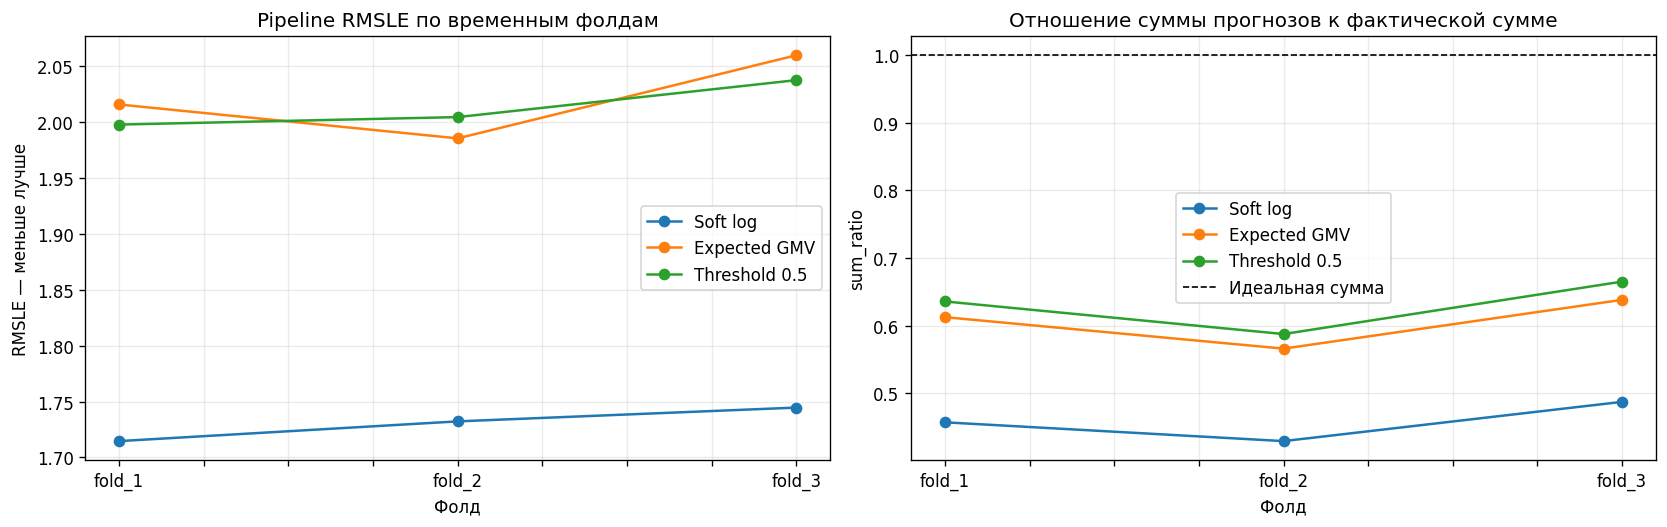

In [15]:
# Полный baseline на трёх expanding-window фолдах.
#
# Сохраняем:
# - OOF-вероятности классификатора;
# - OOF-прогнозы log1p(GMV) регрессора;
# - историю обучения LightGBM;
# - метрики каждого фолда;
# - три способа объединения стадий.

from time import perf_counter


baseline_started = perf_counter()

baseline_oof_probability = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)
baseline_oof_predicted_log = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)

baseline_histories = {}
baseline_records = []


for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    # Срезы не создают вторую полную копию исходной матрицы.
    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train_class = y_nonzero[train_slice]
    y_valid_class = y_nonzero[valid_slice]

    y_train_gmv = y_gmv[train_slice]
    y_valid_gmv = y_gmv[valid_slice]

    # ------------------------------------------------------------------
    # Стадия 1: вероятность ненулевого GMV
    # ------------------------------------------------------------------
    classifier_history = {}

    classifier = lgb.LGBMClassifier(
        **BASE_LGBM_PARAMS,
        objective="binary",
        metric="average_precision",
        n_estimators=MAX_BOOST_ROUNDS,
    )

    classifier.fit(
        X_train,
        y_train_class,
        eval_set=[
            (X_train, y_train_class),
            (X_valid, y_valid_class),
        ],
        eval_names=["train", "valid"],
        eval_metric=["average_precision", "binary_logloss"],
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(classifier_history),
        ],
    )

    classifier_best_iteration = int(classifier.best_iteration_)

    valid_probability = classifier.predict_proba(
        X_valid,
        num_iteration=classifier_best_iteration,
    )[:, 1]

    baseline_oof_probability[valid_slice] = valid_probability.astype(
        np.float32,
        copy=False,
    )

    classifier_fold_metrics = classification_metrics(
        y_valid_class,
        valid_probability,
        threshold=0.5,
    )

    del classifier
    _ = gc.collect()

    # ------------------------------------------------------------------
    # Стадия 2: log1p(GMV) только для положительных наблюдений
    # ------------------------------------------------------------------
    train_positive_mask = y_train_class == 1
    valid_positive_mask = y_valid_class == 1

    X_train_positive = X_train.loc[train_positive_mask]
    X_valid_positive = X_valid.loc[valid_positive_mask]

    y_train_positive_log = np.log1p(
        y_train_gmv[train_positive_mask]
    )
    y_valid_positive_log = np.log1p(
        y_valid_gmv[valid_positive_mask]
    )

    regressor_history = {}

    regressor = lgb.LGBMRegressor(
        **BASE_LGBM_PARAMS,
        objective="regression_l2",
        metric="rmse",
        n_estimators=MAX_BOOST_ROUNDS,
    )

    regressor.fit(
        X_train_positive,
        y_train_positive_log,
        eval_set=[
            (X_train_positive, y_train_positive_log),
            (X_valid_positive, y_valid_positive_log),
        ],
        eval_names=["train", "valid"],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(regressor_history),
        ],
    )

    regressor_best_iteration = int(regressor.best_iteration_)

    # Прогноз нужен для всех строк validation, включая фактические нули.
    valid_predicted_log = regressor.predict(
        X_valid,
        num_iteration=regressor_best_iteration,
    )

    valid_predicted_log = np.maximum(
        valid_predicted_log,
        0.0,
    )

    baseline_oof_predicted_log[valid_slice] = (
        valid_predicted_log.astype(np.float32, copy=False)
    )

    regressor_fold_metrics = positive_regression_metrics(
        y_valid_gmv[valid_positive_mask],
        valid_predicted_log[valid_positive_mask],
    )

    # ------------------------------------------------------------------
    # Объединение двух стадий
    # ------------------------------------------------------------------

    # Основная RMSLE-ориентированная формула:
    # E[log1p(GMV) | X] ≈ P(GMV > 0 | X) * E[log1p(GMV) | GMV > 0, X]
    prediction_soft_log = np.expm1(
        valid_probability * valid_predicted_log
    )

    # Диагностическая формула ожидаемого GMV в исходной шкале.
    prediction_expected_gmv = (
        valid_probability * np.expm1(valid_predicted_log)
    )

    # Диагностический вариант с жёстким порогом.
    prediction_threshold_05 = np.where(
        valid_probability >= 0.5,
        np.expm1(valid_predicted_log),
        0.0,
    )

    soft_log_metrics = pipeline_metrics(
        y_valid_gmv,
        prediction_soft_log,
    )
    expected_gmv_metrics = pipeline_metrics(
        y_valid_gmv,
        prediction_expected_gmv,
    )
    threshold_metrics = pipeline_metrics(
        y_valid_gmv,
        prediction_threshold_05,
    )

    fold_duration = perf_counter() - fold_started

    record = {
        "fold": fold_name,
        "train_rows": len(X_train),
        "valid_rows": len(X_valid),
        "classifier_best_iteration": classifier_best_iteration,
        "regressor_best_iteration": regressor_best_iteration,
        "duration_seconds": fold_duration,
    }

    record.update({
        f"classifier_{metric}": value
        for metric, value in classifier_fold_metrics.items()
    })
    record.update({
        f"regressor_{metric}": value
        for metric, value in regressor_fold_metrics.items()
    })
    record.update({
        f"soft_log_{metric}": value
        for metric, value in soft_log_metrics.items()
    })
    record.update({
        f"expected_gmv_{metric}": value
        for metric, value in expected_gmv_metrics.items()
    })
    record.update({
        f"threshold_05_{metric}": value
        for metric, value in threshold_metrics.items()
    })

    baseline_records.append(record)

    baseline_histories[fold_name] = {
        "classifier": classifier_history,
        "regressor": regressor_history,
    }

    print(
        f"{fold_name}: "
        f"AP={classifier_fold_metrics['average_precision']:.5f}, "
        f"recall={classifier_fold_metrics['recall']:.5f}, "
        f"F2={classifier_fold_metrics['f2']:.5f}, "
        f"RMSLE={soft_log_metrics['rmsle']:.5f}, "
        f"sum_ratio={soft_log_metrics['sum_ratio']:.5f}, "
        f"time={fold_duration:.1f}s"
    )

    del (
        regressor,
        X_train_positive,
        X_valid_positive,
        y_train_positive_log,
        y_valid_positive_log,
        prediction_soft_log,
        prediction_expected_gmv,
        prediction_threshold_05,
    )
    _ = gc.collect()


baseline_duration = perf_counter() - baseline_started

baseline_results = (
    pd.DataFrame(baseline_records)
    .set_index("fold")
)

# Validation-части трёх фолдов должны быть непересекающимися.
baseline_oof_mask = (
    np.isfinite(baseline_oof_probability)
    & np.isfinite(baseline_oof_predicted_log)
)

expected_oof_rows = sum(
    split["valid"].stop - split["valid"].start
    for split in TUNING_SPLITS.values()
)

assert int(baseline_oof_mask.sum()) == expected_oof_rows, (
    f"Получено {int(baseline_oof_mask.sum()):,} OOF-строк, "
    f"ожидалось {expected_oof_rows:,}."
)

# ----------------------------------------------------------------------
# Общие OOF-метрики по всем трём validation-периодам
# ----------------------------------------------------------------------
oof_actual_class = y_nonzero[baseline_oof_mask]
oof_actual_gmv = y_gmv[baseline_oof_mask]

oof_probability = baseline_oof_probability[
    baseline_oof_mask
].astype(np.float64)

oof_predicted_log = baseline_oof_predicted_log[
    baseline_oof_mask
].astype(np.float64)

oof_positive_mask = oof_actual_class == 1

oof_prediction_soft_log = np.expm1(
    oof_probability * oof_predicted_log
)
oof_prediction_expected_gmv = (
    oof_probability * np.expm1(oof_predicted_log)
)
oof_prediction_threshold_05 = np.where(
    oof_probability >= 0.5,
    np.expm1(oof_predicted_log),
    0.0,
)

baseline_oof_metrics = pd.DataFrame(
    {
        "classifier": classification_metrics(
            oof_actual_class,
            oof_probability,
            threshold=0.5,
        ),
        "positive_regressor": positive_regression_metrics(
            oof_actual_gmv[oof_positive_mask],
            oof_predicted_log[oof_positive_mask],
        ),
        "pipeline_soft_log": pipeline_metrics(
            oof_actual_gmv,
            oof_prediction_soft_log,
        ),
        "pipeline_expected_gmv": pipeline_metrics(
            oof_actual_gmv,
            oof_prediction_expected_gmv,
        ),
        "pipeline_threshold_05": pipeline_metrics(
            oof_actual_gmv,
            oof_prediction_threshold_05,
        ),
    }
).T


print()
print(f"OOF rows: {int(baseline_oof_mask.sum()):,}")
print(f"Total baseline duration: {baseline_duration / 60:.1f} minutes")

display(
    baseline_results[
        [
            "classifier_best_iteration",
            "regressor_best_iteration",
            "classifier_average_precision",
            "classifier_recall",
            "classifier_f2",
            "regressor_rmse_log",
            "soft_log_rmsle",
            "soft_log_sum_ratio",
            "expected_gmv_rmsle",
            "threshold_05_rmsle",
            "duration_seconds",
        ]
    ]
)

display(baseline_oof_metrics)

# ----------------------------------------------------------------------
# Стабильность качества по временным фолдам
# ----------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 4.5),
)

baseline_results[
    [
        "soft_log_rmsle",
        "expected_gmv_rmsle",
        "threshold_05_rmsle",
    ]
].rename(
    columns={
        "soft_log_rmsle": "Soft log",
        "expected_gmv_rmsle": "Expected GMV",
        "threshold_05_rmsle": "Threshold 0.5",
    }
).plot(
    ax=axes[0],
    marker="o",
)

axes[0].set_title("Pipeline RMSLE по временным фолдам")
axes[0].set_xlabel("Фолд")
axes[0].set_ylabel("RMSLE — меньше лучше")
axes[0].grid(alpha=0.25)

baseline_results[
    [
        "soft_log_sum_ratio",
        "expected_gmv_sum_ratio",
        "threshold_05_sum_ratio",
    ]
].rename(
    columns={
        "soft_log_sum_ratio": "Soft log",
        "expected_gmv_sum_ratio": "Expected GMV",
        "threshold_05_sum_ratio": "Threshold 0.5",
    }
).plot(
    ax=axes[1],
    marker="o",
)

axes[1].axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Идеальная сумма",
)
axes[1].set_title("Отношение суммы прогнозов к фактической сумме")
axes[1].set_xlabel("Фолд")
axes[1].set_ylabel("sum_ratio")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

Baseline выглядит устойчиво:
- AP держится около 0.885, а recall — 0.80–0.83.
- Ошибка положительного регрессора стабильна: RMSE(log) ≈ 1.12.
- RMSLE постепенно ухудшается 1.715 → 1.745, что указывает на умеренный временной drift.
- soft_log уверенно лучше остальных способов объединения.
- Исправлять sum_ratio=0.458 простым умножением нельзя: это может ухудшить RMSLE. Низкая сумма при небольшом log_bias — эффект длинного хвоста GMV.

,rmsle,zero_rows_rmse_log,positive_rows_rmse_log,zero_mse_contribution,positive_mse_contribution,positive_error_share,log_bias,sum_ratio
method,,,,,,,,
soft_log,1.730708,1.746433,1.718228,1.343350,1.651999,0.551521,0.079031,0.457764
expected_gmv,2.020641,2.698571,1.250913,3.207398,0.875593,0.214449,0.935431,0.605277
threshold_05,2.013386,2.127512,1.918787,1.993559,2.060163,0.508215,0.133024,0.629244
oracle_classifier,0.836895,0.000000,1.118786,0.000000,0.700394,1.000000,0.017432,0.596150


,threshold,precision,recall,f2,pipeline_rmsle,sum_ratio,false_positive,false_negative
criterion,,,,,,,,
maximum_f2,0.18,0.639443,0.967442,0.877427,2.310575,0.733143,224562.0,13403.0
minimum_hard_pipeline_rmsle,0.53,0.798334,0.793366,0.794355,2.011175,0.618928,82501.0,85063.0
recall_at_least_0.90,0.35,0.720516,0.901812,0.858604,2.090919,0.678326,144002.0,40420.0


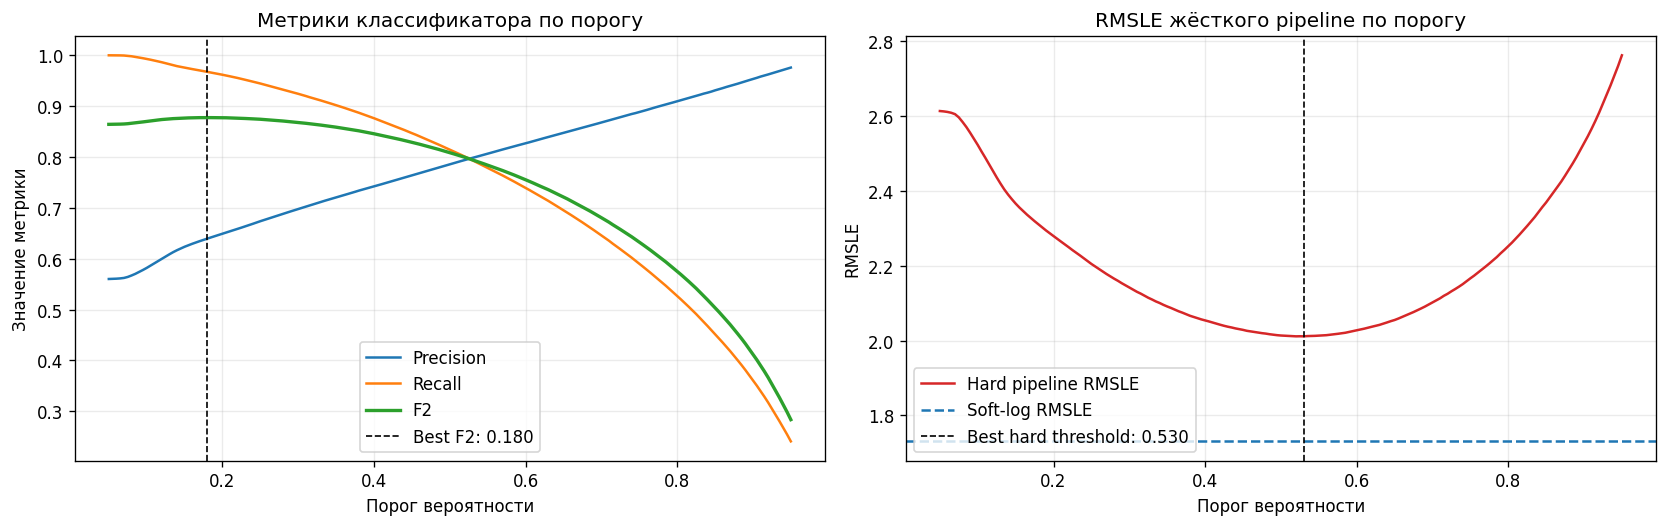

In [16]:
# Декомпозиция OOF-ошибки и подбор рабочего порога классификатора.
#
# Holdout 2026-01-14 не используется, поэтому утечки в финальную
# оценку здесь нет.

actual_log = np.log1p(oof_actual_gmv)

zero_mask = oof_actual_class == 0
positive_mask = ~zero_mask

prediction_log_by_method = {
    # Основной мягкий двухстадийный прогноз.
    "soft_log": oof_probability * oof_predicted_log,

    # Умножение GMV в исходной шкале.
    "expected_gmv": np.log1p(
        oof_probability * np.expm1(oof_predicted_log)
    ),

    # Жёсткий baseline при пороге 0.5.
    "threshold_05": np.where(
        oof_probability >= 0.5,
        oof_predicted_log,
        0.0,
    ),

    # Диагностический верхний ориентир:
    # классификатор знает истинный класс, но величину GMV
    # по-прежнему предсказывает регрессор.
    "oracle_classifier": np.where(
        positive_mask,
        oof_predicted_log,
        0.0,
    ),
}

error_decomposition_records = []

for method, predicted_log in prediction_log_by_method.items():
    squared_error = np.square(predicted_log - actual_log)

    zero_mse_contribution = float(
        squared_error[zero_mask].sum() / len(squared_error)
    )
    positive_mse_contribution = float(
        squared_error[positive_mask].sum() / len(squared_error)
    )

    predicted_gmv = np.expm1(predicted_log)

    error_decomposition_records.append(
        {
            "method": method,
            "rmsle": np.sqrt(squared_error.mean()),
            "zero_rows_rmse_log": np.sqrt(
                squared_error[zero_mask].mean()
            ),
            "positive_rows_rmse_log": np.sqrt(
                squared_error[positive_mask].mean()
            ),
            "zero_mse_contribution": zero_mse_contribution,
            "positive_mse_contribution": positive_mse_contribution,
            "positive_error_share": (
                positive_mse_contribution
                / squared_error.mean()
            ),
            "log_bias": np.mean(predicted_log - actual_log),
            "sum_ratio": (
                predicted_gmv.sum() / oof_actual_gmv.sum()
            ),
        }
    )

error_decomposition = (
    pd.DataFrame(error_decomposition_records)
    .set_index("method")
)

display(error_decomposition)


# ----------------------------------------------------------------------
# Поиск рабочего порога
# ----------------------------------------------------------------------
# Порог влияет на recall/F2 и жёсткий pipeline, но не влияет
# на основной soft_log-прогноз.

threshold_grid = np.linspace(
    0.05,
    0.95,
    181,
)

threshold_records = []

actual_positive_count = int(positive_mask.sum())

for threshold in threshold_grid:
    predicted_positive = oof_probability >= threshold

    true_positive = int(
        np.count_nonzero(predicted_positive & positive_mask)
    )
    false_positive = int(
        np.count_nonzero(predicted_positive & zero_mask)
    )
    false_negative = actual_positive_count - true_positive

    precision = (
        true_positive / (true_positive + false_positive)
        if true_positive + false_positive > 0
        else 0.0
    )
    recall = true_positive / actual_positive_count

    f2 = (
        5.0 * precision * recall
        / (4.0 * precision + recall)
        if precision + recall > 0
        else 0.0
    )

    hard_prediction_log = np.where(
        predicted_positive,
        oof_predicted_log,
        0.0,
    )

    hard_squared_error = np.square(
        hard_prediction_log - actual_log
    )

    threshold_records.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f2": f2,
            "pipeline_rmsle": np.sqrt(
                hard_squared_error.mean()
            ),
            "sum_ratio": (
                np.expm1(hard_prediction_log).sum()
                / oof_actual_gmv.sum()
            ),
            "false_positive": false_positive,
            "false_negative": false_negative,
        }
    )

threshold_diagnostics = pd.DataFrame(threshold_records)

best_f2_index = threshold_diagnostics["f2"].idxmax()
best_rmsle_index = threshold_diagnostics[
    "pipeline_rmsle"
].idxmin()

best_f2_row = threshold_diagnostics.loc[best_f2_index]
best_rmsle_row = threshold_diagnostics.loc[best_rmsle_index]

threshold_choices = [
    {
        "criterion": "maximum_f2",
        **best_f2_row.to_dict(),
    },
    {
        "criterion": "minimum_hard_pipeline_rmsle",
        **best_rmsle_row.to_dict(),
    },
]

# Дополнительная рабочая точка с приоритетом recall.
recall_target = 0.90

recall_candidates = threshold_diagnostics.loc[
    threshold_diagnostics["recall"] >= recall_target
]

if not recall_candidates.empty:
    recall_target_row = recall_candidates.sort_values(
        ["precision", "f2"],
        ascending=False,
    ).iloc[0]

    threshold_choices.append(
        {
            "criterion": f"recall_at_least_{recall_target:.2f}",
            **recall_target_row.to_dict(),
        }
    )

threshold_choice_summary = (
    pd.DataFrame(threshold_choices)
    .set_index("criterion")
)

display(threshold_choice_summary)


# ----------------------------------------------------------------------
# Визуализация компромисса между precision, recall и F2
# ----------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 4.5),
)

axes[0].plot(
    threshold_diagnostics["threshold"],
    threshold_diagnostics["precision"],
    label="Precision",
)
axes[0].plot(
    threshold_diagnostics["threshold"],
    threshold_diagnostics["recall"],
    label="Recall",
)
axes[0].plot(
    threshold_diagnostics["threshold"],
    threshold_diagnostics["f2"],
    label="F2",
    linewidth=2,
)

axes[0].axvline(
    best_f2_row["threshold"],
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Best F2: {best_f2_row['threshold']:.3f}",
)
axes[0].set_title("Метрики классификатора по порогу")
axes[0].set_xlabel("Порог вероятности")
axes[0].set_ylabel("Значение метрики")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    threshold_diagnostics["threshold"],
    threshold_diagnostics["pipeline_rmsle"],
    color="tab:red",
    label="Hard pipeline RMSLE",
)
axes[1].axhline(
    baseline_oof_metrics.loc[
        "pipeline_soft_log",
        "rmsle",
    ],
    color="tab:blue",
    linestyle="--",
    label="Soft-log RMSLE",
)
axes[1].axvline(
    best_rmsle_row["threshold"],
    color="black",
    linestyle="--",
    linewidth=1,
    label=(
        "Best hard threshold: "
        f"{best_rmsle_row['threshold']:.3f}"
    ),
)
axes[1].set_title("RMSLE жёсткого pipeline по порогу")
axes[1].set_xlabel("Порог вероятности")
axes[1].set_ylabel("RMSLE")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

Диагностика показывает, что главный резерв — классификатор:
- При идеальном определении нулей RMSLE снизился бы с 1.731 до 0.837.
- Ошибка soft-log почти поровну распределена между нулевыми и положительными строками.
- Порог 0.18 даёт отличный recall 0.967 и F2 0.877, но создаёт 224 тысячи false positive и ухудшает pipeline RMSLE до 2.31.
- Поэтому порог используем только для оценки recall/F2. Финальный прогноз оставляем мягким.
- Optuna логичнее оптимизировать непосредственно soft-log RMSLE, контролируя AP, recall и F2 как вторичные метрики.

## 8. Stage 1 — Optuna для LightGBM-классификатора

Отдельная Optuna-study максимизирует средний out-of-time Average Precision. F2 и recall сохраняются как дополнительные свойства trial.

Настраиваемые параметры: `learning_rate`, `num_leaves`, `min_child_samples`, `max_bin`, `feature_fraction`, `bagging_fraction`, `bagging_freq`, `lambda_l1`, `lambda_l2`.

Каждый trial должен:

1. пройти три временных фолда;
2. использовать early stopping;
3. сохранить AP, logloss, Brier, максимальную F2, recall и `best_iteration` по каждому фолду;
4. вернуть средний AP;
5. освобождать промежуточные модели и массивы после фолда.

Начальный бюджет — 40 trials, с возможностью продолжить сохранённую SQLite-study.

In [18]:
# Optuna: настройка классификатора по итоговому soft-log RMSLE.
#
# Регрессор временно фиксирован на baseline OOF-прогнозах.
# Это позволяет оптимизировать именно влияние вероятностей
# классификатора на итоговую метрику и не обучать регрессор
# заново в каждом trial.
#
# SQLite-хранилище позволяет продолжить study после остановки ядра.

import gc
import optuna
import numpy as np

from pathlib import Path
from time import perf_counter


CLASSIFIER_STUDY_NAME = "classifier_soft_log_rmsle_v1"
CLASSIFIER_REPORT_THRESHOLD = 0.18

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
assert ARTIFACT_DIR.is_dir()

classifier_storage_path = (
    ARTIFACT_DIR / "classifier_optuna.db"
).resolve()

classifier_storage_path = (
    ARTIFACT_DIR / "classifier_optuna.db"
).resolve()

classifier_storage_url = (
    f"sqlite:///{classifier_storage_path.as_posix()}"
)

baseline_mean_fold_rmsle = float(
    baseline_results["soft_log_rmsle"].mean()
)


def classifier_objective(trial):
    max_depth = trial.suggest_int(
        "max_depth",
        6,
        11,
    )

    max_num_leaves = min(
        255,
        2 ** max_depth,
    )

    trial_params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.08,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            31,
            max_num_leaves,
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            200,
            1_500,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.70,
            1.00,
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.65,
            1.00,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            10.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            10.0,
            log=True,
        ),
    }

    model_params = {
        **BASE_LGBM_PARAMS,
        **trial_params,
    }

    fold_rmsle_values = []
    fold_ap_values = []
    fold_recall_values = []
    fold_f2_values = []
    fold_best_iterations = []

    for fold_number, (fold_name, split) in enumerate(
        TUNING_SPLITS.items()
    ):
        train_slice = split["train"]
        valid_slice = split["valid"]

        X_train = X.iloc[train_slice]
        X_valid = X.iloc[valid_slice]

        y_train_class = y_nonzero[train_slice]
        y_valid_class = y_nonzero[valid_slice]
        y_valid_gmv = y_gmv[valid_slice]

        # Независимый OOF-прогноз baseline-регрессора
        # для validation-части текущего фолда.
        fixed_regressor_log = (
            baseline_oof_predicted_log[valid_slice]
            .astype(np.float64)
        )

        assert np.isfinite(fixed_regressor_log).all()

        classifier = lgb.LGBMClassifier(
            **model_params,
            objective="binary",
            metric="average_precision",
            n_estimators=MAX_BOOST_ROUNDS,
        )

        classifier.fit(
            X_train,
            y_train_class,
            eval_set=[
                (X_valid, y_valid_class),
            ],
            eval_names=["valid"],
            eval_metric="average_precision",
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False,
                ),
            ],
        )

        best_iteration = int(
            classifier.best_iteration_
        )

        valid_probability = classifier.predict_proba(
            X_valid,
            num_iteration=best_iteration,
        )[:, 1]

        # Для soft-log:
        #
        # prediction = expm1(probability * predicted_log)
        # log1p(prediction) = probability * predicted_log
        #
        # Поэтому RMSLE можно считать непосредственно
        # в логарифмической шкале без expm1/log1p.
        pipeline_predicted_log = (
            valid_probability * fixed_regressor_log
        )
        actual_log = np.log1p(y_valid_gmv)

        fold_rmsle = float(
            np.sqrt(
                np.mean(
                    np.square(
                        pipeline_predicted_log - actual_log
                    )
                )
            )
        )

        classifier_metrics_at_threshold = (
            classification_metrics(
                y_valid_class,
                valid_probability,
                threshold=CLASSIFIER_REPORT_THRESHOLD,
            )
        )

        fold_rmsle_values.append(fold_rmsle)
        fold_ap_values.append(
            classifier_metrics_at_threshold[
                "average_precision"
            ]
        )
        fold_recall_values.append(
            classifier_metrics_at_threshold["recall"]
        )
        fold_f2_values.append(
            classifier_metrics_at_threshold["f2"]
        )
        fold_best_iterations.append(best_iteration)

        del classifier
        _ = gc.collect()

        # Pruning начинается после обработки двух временных фолдов.
        partial_mean_rmsle = float(
            np.mean(fold_rmsle_values)
        )

        trial.report(
            partial_mean_rmsle,
            step=fold_number,
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_rmsle = float(np.mean(fold_rmsle_values))

    trial.set_user_attr(
        "mean_average_precision",
        float(np.mean(fold_ap_values)),
    )
    trial.set_user_attr(
        "mean_recall_at_018",
        float(np.mean(fold_recall_values)),
    )
    trial.set_user_attr(
        "mean_f2_at_018",
        float(np.mean(fold_f2_values)),
    )
    trial.set_user_attr(
        "rmsle_std",
        float(np.std(fold_rmsle_values)),
    )
    trial.set_user_attr(
        "best_iterations",
        fold_best_iterations,
    )

    return mean_rmsle


def print_classifier_trial(study, trial):
    if trial.state != optuna.trial.TrialState.COMPLETE:
        return

    print(
        f"Trial {trial.number:02d}: "
        f"RMSLE={trial.value:.6f}, "
        f"AP={trial.user_attrs['mean_average_precision']:.6f}, "
        f"recall@0.18="
        f"{trial.user_attrs['mean_recall_at_018']:.6f}, "
        f"F2@0.18="
        f"{trial.user_attrs['mean_f2_at_018']:.6f}"
    )


classifier_sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=8,
)

classifier_pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=1,
)

classifier_study = optuna.create_study(
    study_name=CLASSIFIER_STUDY_NAME,
    storage=classifier_storage_url,
    load_if_exists=True,
    direction="minimize",
    sampler=classifier_sampler,
    pruner=classifier_pruner,
)

# При повторном запуске выполняются только оставшиеся trials.
completed_trial_count = len(classifier_study.trials)

remaining_trial_count = max(
    0,
    N_TRIALS_CLASSIFIER - completed_trial_count,
)

print(f"Study: {CLASSIFIER_STUDY_NAME}")
print(f"Existing trials: {completed_trial_count}")
print(f"Remaining trials: {remaining_trial_count}")
print(
    "Baseline mean fold RMSLE: "
    f"{baseline_mean_fold_rmsle:.6f}"
)

classifier_tuning_started = perf_counter()

if remaining_trial_count > 0:
    classifier_study.optimize(
        classifier_objective,
        n_trials=remaining_trial_count,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        callbacks=[print_classifier_trial],
    )

classifier_tuning_duration = (
    perf_counter() - classifier_tuning_started
)

classifier_best_trial = classifier_study.best_trial
classifier_best_params = {
    **BASE_LGBM_PARAMS,
    **classifier_best_trial.params,
}

classifier_trials = (
    classifier_study.trials_dataframe()
    .sort_values("value")
)

print()
print(
    "Tuning duration: "
    f"{classifier_tuning_duration / 60:.1f} minutes"
)
print(
    "Best mean fold RMSLE: "
    f"{classifier_best_trial.value:.6f}"
)
print(
    "Improvement over baseline: "
    f"{baseline_mean_fold_rmsle - classifier_best_trial.value:.6f}"
)
print(
    "Best mean AP: "
    f"{classifier_best_trial.user_attrs['mean_average_precision']:.6f}"
)
print(
    "Best recall@0.18: "
    f"{classifier_best_trial.user_attrs['mean_recall_at_018']:.6f}"
)
print(
    "Best F2@0.18: "
    f"{classifier_best_trial.user_attrs['mean_f2_at_018']:.6f}"
)
print()
print("Best classifier parameters:")
display(
    pd.Series(
        classifier_best_trial.params,
        name="value",
    ).to_frame()
)

display(
    classifier_trials.head(10)
)

[I 2026-08-17 02:08:22,684] A new study created in RDB with name: classifier_soft_log_rmsle_v1


Study: classifier_soft_log_rmsle_v1
Existing trials: 0
Remaining trials: 40
Baseline mean fold RMSLE: 1.730475


[I 2026-08-17 02:11:01,683] Trial 0 finished with value: 1.7306721450299642 and parameters: {'max_depth': 8, 'learning_rate': 0.07471658997996457, 'num_leaves': 195, 'min_child_samples': 668, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7045980821176709, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 1.7306721450299642.


Trial 00: RMSLE=1.730672, AP=0.885534, recall@0.18=0.967477, F2@0.18=0.877442


[I 2026-08-17 02:14:56,421] Trial 1 finished with value: 1.7305818854686337 and parameters: {'max_depth': 9, 'learning_rate': 0.05337429672856024, 'num_leaves': 35, 'min_child_samples': 1412, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7243186887373967, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 1.7305818854686337.


...

Trial 38: RMSLE=1.730318, AP=0.885682, recall@0.18=0.967601, F2@0.18=0.877377


[I 2026-08-17 06:27:57,740] Trial 39 finished with value: 1.7303632841173242 and parameters: {'max_depth': 11, 'learning_rate': 0.03517576029792052, 'num_leaves': 152, 'min_child_samples': 202, 'subsample': 0.7754636895897592, 'colsample_bytree': 0.720204433787869, 'reg_alpha': 0.02956875415929876, 'reg_lambda': 0.5200286700312368}. Best is trial 31 with value: 1.730082987943427.


Trial 39: RMSLE=1.730363, AP=0.885620, recall@0.18=0.967606, F2@0.18=0.877345

Tuning duration: 259.6 minutes
Best mean fold RMSLE: 1.730083
Improvement over baseline: 0.000392
Best mean AP: 0.885689
Best recall@0.18: 0.967426
Best F2@0.18: 0.877484

Best classifier parameters:


,value
max_depth,11.000000
learning_rate,0.024970
num_leaves,176.000000
min_child_samples,227.000000
subsample,0.820934
colsample_bytree,0.836837
reg_alpha,3.087083
reg_lambda,0.269853


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iterations,user_attrs_mean_average_precision,user_attrs_mean_f2_at_018,user_attrs_mean_recall_at_018,user_attrs_rmsle_std,state
31,31,1.730083,2026-08-17 05:28:44.367811,2026-08-17 05:36:33.119429,0 days 00:07:48.751618,0.836837,0.024970,11,227,176,3.087083,0.269853,0.820934,"[430, 415, 456]",0.885689,0.877484,0.967426,0.012122,COMPLETE
13,13,1.730136,2026-08-17 03:21:02.475458,2026-08-17 03:26:56.143517,0 days 00:05:53.668059,0.921536,0.028570,10,279,182,2.245370,0.183365,0.841697,"[358, 347, 286]",0.885651,0.877542,0.967561,0.012117,COMPLETE
21,21,1.730138,2026-08-17 04:10:46.936463,2026-08-17 04:20:40.987049,0 days 00:09:54.050586,0.841598,0.020298,11,222,167,5.465031,1.251231,0.915462,"[453, 562, 485]",0.885700,0.877460,0.967589,0.012135,COMPLETE
10,10,1.730150,2026-08-17 02:55:09.256312,2026-08-17 03:03:51.951689,0 days 00:08:42.695377,0.848160,0.020397,11,202,152,9.525883,0.509650,0.937441,"[554, 629, 589]",0.885684,0.877493,0.967503,0.012162,COMPLETE
27,27,1.730169,2026-08-17 04:56:02.085485,2026-08-17 05:04:07.171519,0 days 00:08:05.086034,0.843789,0.025761,11,237,177,3.416535,0.344600,0.864042,"[391, 417, 421]",0.885649,0.877457,0.967512,0.012054,COMPLETE
32,32,1.730185,2026-08-17 05:36:33.482957,2026-08-17 05:44:04.269696,0 days 00:07:30.786739,0.825952,0.024494,11,224,188,2.315192,0.263982,0.835346,"[378, 347, 446]",0.885677,0.877396,0.967483,0.012181,COMPLETE
9,9,1.730191,2026-08-17 02:46:36.325160,2026-08-17 02:55:09.019535,0 days 00:08:32.694375,0.811296,0.020344,11,203,136,6.971880,0.615968,0.917915,"[522, 585, 698]",0.885701,0.877431,0.967491,0.012217,COMPLETE
14,14,1.730203,2026-08-17 03:26:56.396734,2026-08-17 03:32:34.311381,0 days 00:05:37.914647,0.940069,0.028977,10,281,189,1.616835,0.183697,0.704653,"[339, 296, 303]",0.885634,0.877454,0.967345,0.012060,COMPLETE
33,33,1.730207,2026-08-17 05:44:04.636685,2026-08-17 05:53:30.829658,0 days 00:09:26.192973,0.786951,0.022151,11,267,166,9.986576,0.068003,0.810054,"[478, 570, 543]",0.885691,0.877535,0.967647,0.012106,COMPLETE
12,12,1.730220,2026-08-17 03:12:30.604848,2026-08-17 03:21:02.244949,0 days 00:08:31.640101,0.800127,0.020551,10,313,142,9.560107,0.708531,0.918950,"[495, 794, 618]",0.885704,0.877516,0.967627,0.012214,COMPLETE


Повтороное обучение классификатора с лучшими параметриами

In [19]:
# Повторное OOF-обучение классификатора с лучшими параметрами Optuna.

tuned_classifier_started = perf_counter()

tuned_classifier_oof_probability = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)

tuned_classifier_histories = {}
tuned_classifier_records = []
tuned_classifier_best_iterations = []

for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train_class = y_nonzero[train_slice]
    y_valid_class = y_nonzero[valid_slice]
    y_valid_gmv = y_gmv[valid_slice]

    classifier_history = {}

    classifier = lgb.LGBMClassifier(
        **classifier_best_params,
        objective="binary",
        metric="average_precision",
        n_estimators=MAX_BOOST_ROUNDS,
    )

    classifier.fit(
        X_train,
        y_train_class,
        eval_set=[(X_valid, y_valid_class)],
        eval_names=["valid"],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(classifier_history),
        ],
    )

    best_iteration = int(classifier.best_iteration_)

    valid_probability = classifier.predict_proba(
        X_valid,
        num_iteration=best_iteration,
    )[:, 1]

    tuned_classifier_oof_probability[valid_slice] = (
        valid_probability.astype(np.float32, copy=False)
    )

    fixed_regressor_log = (
        baseline_oof_predicted_log[valid_slice]
        .astype(np.float64)
    )

    soft_log_prediction = np.expm1(
        valid_probability * fixed_regressor_log
    )

    classifier_fold_metrics = classification_metrics(
        y_valid_class,
        valid_probability,
        threshold=CLASSIFIER_REPORT_THRESHOLD,
    )
    pipeline_fold_metrics = pipeline_metrics(
        y_valid_gmv,
        soft_log_prediction,
    )

    tuned_classifier_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "average_precision": classifier_fold_metrics[
                "average_precision"
            ],
            "recall_at_018": classifier_fold_metrics["recall"],
            "f2_at_018": classifier_fold_metrics["f2"],
            "soft_log_rmsle": pipeline_fold_metrics["rmsle"],
            "soft_log_sum_ratio": pipeline_fold_metrics["sum_ratio"],
            "baseline_rmsle": baseline_results.loc[
                fold_name,
                "soft_log_rmsle",
            ],
            "rmsle_improvement": (
                baseline_results.loc[
                    fold_name,
                    "soft_log_rmsle",
                ]
                - pipeline_fold_metrics["rmsle"]
            ),
            "duration_seconds": perf_counter() - fold_started,
        }
    )

    tuned_classifier_histories[fold_name] = classifier_history
    tuned_classifier_best_iterations.append(best_iteration)

    print(
        f"{fold_name}: "
        f"iteration={best_iteration}, "
        f"AP={classifier_fold_metrics['average_precision']:.6f}, "
        f"recall@0.18={classifier_fold_metrics['recall']:.6f}, "
        f"F2@0.18={classifier_fold_metrics['f2']:.6f}, "
        f"RMSLE={pipeline_fold_metrics['rmsle']:.6f}"
    )

    del classifier
    _ = gc.collect()


tuned_classifier_fold_results = (
    pd.DataFrame(tuned_classifier_records)
    .set_index("fold")
)

tuned_classifier_oof_mask = np.isfinite(
    tuned_classifier_oof_probability
)

assert np.array_equal(
    tuned_classifier_oof_mask,
    baseline_oof_mask,
)

# Проверяем, что повторное обучение воспроизводит Optuna objective.
reproduced_mean_rmsle = float(
    tuned_classifier_fold_results[
        "soft_log_rmsle"
    ].mean()
)

np.testing.assert_allclose(
    reproduced_mean_rmsle,
    classifier_best_trial.value,
    atol=1e-8,
    rtol=0.0,
)

assert (
    tuned_classifier_best_iterations
    == classifier_best_trial.user_attrs["best_iterations"]
)

# Общие OOF-метрики.
comparison_actual_class = y_nonzero[
    tuned_classifier_oof_mask
]
comparison_actual_gmv = y_gmv[
    tuned_classifier_oof_mask
]
comparison_regressor_log = (
    baseline_oof_predicted_log[
        tuned_classifier_oof_mask
    ].astype(np.float64)
)

comparison_records = []

for model_name, probability in {
    "baseline_classifier": (
        baseline_oof_probability[
            tuned_classifier_oof_mask
        ].astype(np.float64)
    ),
    "optuna_classifier": (
        tuned_classifier_oof_probability[
            tuned_classifier_oof_mask
        ].astype(np.float64)
    ),
}.items():
    classifier_result = classification_metrics(
        comparison_actual_class,
        probability,
        threshold=CLASSIFIER_REPORT_THRESHOLD,
    )

    pipeline_prediction = np.expm1(
        probability * comparison_regressor_log
    )
    pipeline_result = pipeline_metrics(
        comparison_actual_gmv,
        pipeline_prediction,
    )

    comparison_records.append(
        {
            "model": model_name,
            "average_precision": classifier_result[
                "average_precision"
            ],
            "logloss": classifier_result["logloss"],
            "brier": classifier_result["brier"],
            "precision_at_018": classifier_result["precision"],
            "recall_at_018": classifier_result["recall"],
            "f2_at_018": classifier_result["f2"],
            "pipeline_rmsle": pipeline_result["rmsle"],
            "pipeline_sum_ratio": pipeline_result["sum_ratio"],
            "pipeline_log_bias": pipeline_result["log_bias"],
        }
    )

tuned_classifier_comparison = (
    pd.DataFrame(comparison_records)
    .set_index("model")
)

print()
print(
    "OOF reproduction: PASS\n"
    f"Duration: "
    f"{(perf_counter() - tuned_classifier_started) / 60:.1f} minutes"
)

display(tuned_classifier_fold_results)
display(tuned_classifier_comparison)

fold_1: iteration=430, AP=0.882911, recall@0.18=0.964616, F2@0.18=0.874365, RMSLE=1.714427
fold_2: iteration=415, AP=0.889022, recall@0.18=0.962732, F2@0.18=0.879309, RMSLE=1.731864
fold_3: iteration=456, AP=0.885135, recall@0.18=0.974931, F2@0.18=0.878778, RMSLE=1.743958

OOF reproduction: PASS
Duration: 6.9 minutes


,best_iteration,average_precision,recall_at_018,f2_at_018,soft_log_rmsle,soft_log_sum_ratio,baseline_rmsle,rmsle_improvement,duration_seconds
fold,,,,,,,,,
fold_1,430,0.882911,0.964616,0.874365,1.714427,0.456761,1.714607,0.000180,121.218142
fold_2,415,0.889022,0.962732,0.879309,1.731864,0.427072,1.732246,0.000382,128.064843
fold_3,456,0.885135,0.974931,0.878778,1.743958,0.485726,1.744573,0.000615,163.114526


,average_precision,logloss,brier,precision_at_018,recall_at_018,f2_at_018,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
model,,,,,,,,,
baseline_classifier,0.88542,0.471835,0.155378,0.639443,0.967442,0.877427,1.730708,0.457764,0.079031
optuna_classifier,0.88551,0.471603,0.155304,0.639651,0.967505,0.877547,1.730311,0.456495,0.076186


Результат воспроизведён и улучшение есть на каждом фолде, но оно практически небольшое: OOF RMSLE снизился на 0.000397 (0.023%). Дальше классификатор не тюним, сохраняем Optuna-вариант и переходим к регрессору.

## 9. Диагностика классификатора

После завершения study строятся:

- история objective и best-so-far;
- важность гиперпараметров Optuna;
- slice plots для наиболее важных параметров;
- learning curves лучшей модели по фолдам;
- Precision–Recall curves;
- precision, recall и F2 как функции threshold;
- матрица ошибок при выбранном диагностическом пороге.

Порог выбирается по OOF-прогнозам для анализа recall/F2, но не применяется к основному мягкому GMV-прогнозу.

In [21]:
# Контракт и smoke-тест RMSLE-метрики для настройки регрессора.
#
# Регрессор предсказывает условный log1p(GMV), а метрика оценивает
# уже итоговый soft-log pipeline с фиксированной вероятностью классификатора.

def make_soft_pipeline_rmsle_metric(probability):
    probability = np.asarray(
        probability,
        dtype=np.float64,
    )

    def soft_pipeline_rmsle_metric(
        actual_log,
        predicted_log,
    ):
        assert len(actual_log) == len(probability)

        predicted_log = np.maximum(
            predicted_log,
            0.0,
        )
        pipeline_predicted_log = (
            probability * predicted_log
        )

        metric_value = float(
            np.sqrt(
                np.mean(
                    np.square(
                        pipeline_predicted_log - actual_log
                    )
                )
            )
        )

        return (
            "soft_pipeline_rmsle",
            metric_value,
            False,
        )

    return soft_pipeline_rmsle_metric


# ----------------------------------------------------------------------
# Минимальный тест контракта метрики
# ----------------------------------------------------------------------
test_probability = np.array([0.0, 0.5, 1.0])
test_actual_log = np.array([0.0, 2.0, 3.0])
test_predicted_log = np.array([-1.0, 3.0, 2.5])

test_metric = make_soft_pipeline_rmsle_metric(
    test_probability
)

metric_name, metric_value, greater_is_better = test_metric(
    test_actual_log,
    test_predicted_log,
)

expected_value = np.sqrt(
    np.mean(
        np.square(
            np.array([0.0, 1.5, 2.5])
            - test_actual_log
        )
    )
)

assert metric_name == "soft_pipeline_rmsle"
assert greater_is_better is False
np.testing.assert_allclose(
    metric_value,
    expected_value,
    atol=1e-12,
    rtol=0.0,
)

print("Regressor metric contract: PASS")


# ----------------------------------------------------------------------
# Короткое обучение для проверки интеграции с LightGBM
# ----------------------------------------------------------------------
smoke_split = TUNING_SPLITS["fold_1"]

smoke_train_slice = slice(
    smoke_split["train"].stop - 100_000,
    smoke_split["train"].stop,
)
smoke_valid_slice = slice(
    smoke_split["valid"].start,
    smoke_split["valid"].start + 50_000,
)

X_smoke_train = X.iloc[smoke_train_slice]
X_smoke_valid = X.iloc[smoke_valid_slice]

y_smoke_train_class = y_nonzero[smoke_train_slice]
y_smoke_train_gmv = y_gmv[smoke_train_slice]
y_smoke_valid_class = y_nonzero[smoke_valid_slice]
y_smoke_valid_gmv = y_gmv[smoke_valid_slice]

smoke_train_positive = y_smoke_train_class == 1
smoke_valid_positive = y_smoke_valid_class == 1

smoke_probability = (
    tuned_classifier_oof_probability[smoke_valid_slice]
    .astype(np.float64)
)

assert np.isfinite(smoke_probability).all()

smoke_regressor_history = {}

smoke_regressor = lgb.LGBMRegressor(
    **BASE_LGBM_PARAMS,
    objective="regression_l2",
    metric="None",
    n_estimators=500,
)

smoke_regressor.fit(
    X_smoke_train.loc[smoke_train_positive],
    np.log1p(
        y_smoke_train_gmv[smoke_train_positive]
    ),
    eval_set=[
        (
            X_smoke_valid,
            np.log1p(y_smoke_valid_gmv),
        )
    ],
    eval_names=["valid"],
    eval_metric=make_soft_pipeline_rmsle_metric(
        smoke_probability
    ),
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            first_metric_only=True,
            verbose=False,
        ),
        lgb.record_evaluation(
            smoke_regressor_history
        ),
    ],
)

smoke_predicted_log = np.maximum(
    smoke_regressor.predict(
        X_smoke_valid,
        num_iteration=smoke_regressor.best_iteration_,
    ),
    0.0,
)

smoke_pipeline_prediction = np.expm1(
    smoke_probability * smoke_predicted_log
)

smoke_reported_rmsle = smoke_regressor.best_score_[
    "valid"
]["soft_pipeline_rmsle"]

smoke_recomputed_rmsle = pipeline_metrics(
    y_smoke_valid_gmv,
    smoke_pipeline_prediction,
)["rmsle"]

np.testing.assert_allclose(
    smoke_reported_rmsle,
    smoke_recomputed_rmsle,
    atol=1e-12,
    rtol=1e-10,
)

assert list(
    smoke_regressor_history["valid"]
) == ["soft_pipeline_rmsle"]

print("LightGBM custom metric integration: PASS")
print(
    "Best iteration:",
    smoke_regressor.best_iteration_,
)
print(
    "Pipeline RMSLE:",
    f"{smoke_recomputed_rmsle:.6f}",
)

display(
    pd.DataFrame(
        {
            "positive_regressor": positive_regression_metrics(
                y_smoke_valid_gmv[smoke_valid_positive],
                smoke_predicted_log[smoke_valid_positive],
            ),
            "soft_log_pipeline": pipeline_metrics(
                y_smoke_valid_gmv,
                smoke_pipeline_prediction,
            ),
        }
    ).T
)

del smoke_regressor
_ = gc.collect()

Regressor metric contract: PASS
LightGBM custom metric integration: PASS
Best iteration: 90
Pipeline RMSLE: 1.716201


,rmse_log,mae_log,log_bias,sum_ratio,negative_log_prediction_share,rmsle
positive_regressor,1.125767,0.894956,0.057381,0.609570,0.0,NaN
soft_log_pipeline,NaN,NaN,0.079648,0.460118,NaN,1.716201


In [22]:
# Optuna: настройка положительного регрессора по итоговому
# soft-log RMSLE с фиксированными OOF-вероятностями классификатора.

REGRESSOR_STUDY_NAME = "positive_regressor_soft_log_rmsle_v1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

regressor_storage_path = (
    ARTIFACT_DIR / "regressor_optuna.db"
).resolve()

regressor_storage_url = (
    f"sqlite:///{regressor_storage_path.as_posix()}"
)

baseline_regressor_mean_rmsle = float(
    tuned_classifier_fold_results[
        "soft_log_rmsle"
    ].mean()
)


def regressor_objective(trial):
    max_depth = trial.suggest_int(
        "max_depth",
        6,
        12,
    )

    trial_params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.015,
            0.08,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            31,
            min(255, 2 ** max_depth),
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            100,
            1_200,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.70,
            1.00,
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.65,
            1.00,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            10.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            10.0,
            log=True,
        ),
    }

    model_params = {
        **BASE_LGBM_PARAMS,
        **trial_params,
    }

    fold_rmsle_values = []
    fold_positive_rmse_values = []
    fold_sum_ratio_values = []
    fold_log_bias_values = []
    fold_best_iterations = []

    for fold_number, (fold_name, split) in enumerate(
        TUNING_SPLITS.items()
    ):
        train_slice = split["train"]
        valid_slice = split["valid"]

        X_train = X.iloc[train_slice]
        X_valid = X.iloc[valid_slice]

        y_train_class = y_nonzero[train_slice]
        y_train_gmv = y_gmv[train_slice]

        y_valid_class = y_nonzero[valid_slice]
        y_valid_gmv = y_gmv[valid_slice]

        train_positive = y_train_class == 1
        valid_positive = y_valid_class == 1

        X_train_positive = X_train.loc[
            train_positive
        ]
        y_train_positive_log = np.log1p(
            y_train_gmv[train_positive]
        )

        fixed_probability = (
            tuned_classifier_oof_probability[
                valid_slice
            ].astype(np.float64)
        )

        assert np.isfinite(fixed_probability).all()

        actual_valid_log = np.log1p(
            y_valid_gmv
        )

        regressor = lgb.LGBMRegressor(
            **model_params,
            objective="regression_l2",
            metric="None",
            n_estimators=MAX_BOOST_ROUNDS,
        )

        regressor.fit(
            X_train_positive,
            y_train_positive_log,
            eval_set=[
                (
                    X_valid,
                    actual_valid_log,
                )
            ],
            eval_names=["valid"],
            eval_metric=make_soft_pipeline_rmsle_metric(
                fixed_probability
            ),
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False,
                ),
            ],
        )

        best_iteration = int(
            regressor.best_iteration_
        )

        valid_predicted_log = np.maximum(
            regressor.predict(
                X_valid,
                num_iteration=best_iteration,
            ),
            0.0,
        )

        pipeline_predicted_log = (
            fixed_probability
            * valid_predicted_log
        )

        fold_rmsle = float(
            np.sqrt(
                np.mean(
                    np.square(
                        pipeline_predicted_log
                        - actual_valid_log
                    )
                )
            )
        )

        positive_metrics = positive_regression_metrics(
            y_valid_gmv[valid_positive],
            valid_predicted_log[valid_positive],
        )

        pipeline_prediction = np.expm1(
            pipeline_predicted_log
        )
        pipeline_result = pipeline_metrics(
            y_valid_gmv,
            pipeline_prediction,
        )

        fold_rmsle_values.append(fold_rmsle)
        fold_positive_rmse_values.append(
            positive_metrics["rmse_log"]
        )
        fold_sum_ratio_values.append(
            pipeline_result["sum_ratio"]
        )
        fold_log_bias_values.append(
            pipeline_result["log_bias"]
        )
        fold_best_iterations.append(
            best_iteration
        )

        del (
            regressor,
            X_train_positive,
            y_train_positive_log,
        )
        _ = gc.collect()

        partial_mean_rmsle = float(
            np.mean(fold_rmsle_values)
        )

        trial.report(
            partial_mean_rmsle,
            step=fold_number,
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_rmsle = float(
        np.mean(fold_rmsle_values)
    )

    trial.set_user_attr(
        "mean_positive_rmse_log",
        float(np.mean(fold_positive_rmse_values)),
    )
    trial.set_user_attr(
        "mean_pipeline_sum_ratio",
        float(np.mean(fold_sum_ratio_values)),
    )
    trial.set_user_attr(
        "mean_pipeline_log_bias",
        float(np.mean(fold_log_bias_values)),
    )
    trial.set_user_attr(
        "rmsle_std",
        float(np.std(fold_rmsle_values)),
    )
    trial.set_user_attr(
        "best_iterations",
        fold_best_iterations,
    )

    return mean_rmsle


def print_regressor_trial(study, trial):
    if trial.state != optuna.trial.TrialState.COMPLETE:
        return

    print(
        f"Trial {trial.number:02d}: "
        f"RMSLE={trial.value:.6f}, "
        f"positive RMSE(log)="
        f"{trial.user_attrs['mean_positive_rmse_log']:.6f}, "
        f"sum_ratio="
        f"{trial.user_attrs['mean_pipeline_sum_ratio']:.6f}"
    )


regressor_sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=8,
)

regressor_pruner = optuna.pruners.MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=1,
)

regressor_study = optuna.create_study(
    study_name=REGRESSOR_STUDY_NAME,
    storage=regressor_storage_url,
    load_if_exists=True,
    direction="minimize",
    sampler=regressor_sampler,
    pruner=regressor_pruner,
)

existing_regressor_trials = len(
    regressor_study.trials
)

remaining_regressor_trials = max(
    0,
    N_TRIALS_REGRESSOR
    - existing_regressor_trials,
)

print(f"Study: {REGRESSOR_STUDY_NAME}")
print(
    f"Existing trials: {existing_regressor_trials}"
)
print(
    f"Remaining trials: {remaining_regressor_trials}"
)
print(
    "Baseline mean fold RMSLE: "
    f"{baseline_regressor_mean_rmsle:.6f}"
)

regressor_tuning_started = perf_counter()

if remaining_regressor_trials > 0:
    regressor_study.optimize(
        regressor_objective,
        n_trials=remaining_regressor_trials,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        callbacks=[print_regressor_trial],
    )

regressor_tuning_duration = (
    perf_counter() - regressor_tuning_started
)

regressor_best_trial = (
    regressor_study.best_trial
)

regressor_best_params = {
    **BASE_LGBM_PARAMS,
    **regressor_best_trial.params,
}

regressor_trials = (
    regressor_study.trials_dataframe()
    .sort_values("value")
)

print()
print(
    "Tuning duration: "
    f"{regressor_tuning_duration / 60:.1f} minutes"
)
print(
    "Best mean fold RMSLE: "
    f"{regressor_best_trial.value:.6f}"
)
print(
    "Improvement over baseline regressor: "
    f"{baseline_regressor_mean_rmsle - regressor_best_trial.value:.6f}"
)
print(
    "Best positive RMSE(log): "
    f"{regressor_best_trial.user_attrs['mean_positive_rmse_log']:.6f}"
)
print(
    "Best pipeline sum_ratio: "
    f"{regressor_best_trial.user_attrs['mean_pipeline_sum_ratio']:.6f}"
)
print(
    "Best pipeline log_bias: "
    f"{regressor_best_trial.user_attrs['mean_pipeline_log_bias']:.6f}"
)

print()
print("Best regressor parameters:")

display(
    pd.Series(
        regressor_best_trial.params,
        name="value",
    ).to_frame()
)

display(
    regressor_trials.head(10)
)

[I 2026-08-17 11:58:36,070] A new study created in RDB with name: positive_regressor_soft_log_rmsle_v1


Study: positive_regressor_soft_log_rmsle_v1
Existing trials: 0
Remaining trials: 40
Baseline mean fold RMSLE: 1.730083


[I 2026-08-17 11:59:57,168] Trial 0 finished with value: 1.7302610994920702 and parameters: {'max_depth': 8, 'learning_rate': 0.07366468743509788, 'num_leaves': 195, 'min_child_samples': 442, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7045980821176709, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 1.7302610994920702.


Trial 00: RMSLE=1.730261, positive RMSE(log)=1.119430, sum_ratio=0.456876


[I 2026-08-17 12:02:54,012] Trial 1 finished with value: 1.7301427048681777 and parameters: {'max_depth': 10, 'learning_rate': 0.04907486599739194, 'num_leaves': 35, 'min_child_samples': 1114, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7243186887373967, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 1.7301427048681777.


...

Trial 38: RMSLE=1.730041, positive RMSE(log)=1.118551, sum_ratio=0.457188


[I 2026-08-17 15:12:39,421] Trial 39 finished with value: 1.7300581205946903 and parameters: {'max_depth': 9, 'learning_rate': 0.030113621860529283, 'num_leaves': 148, 'min_child_samples': 673, 'subsample': 0.7792079747157108, 'colsample_bytree': 0.697201506236536, 'reg_alpha': 0.0024568408812938322, 'reg_lambda': 0.006422448383839601}. Best is trial 28 with value: 1.7299487448424824.


Trial 39: RMSLE=1.730058, positive RMSE(log)=1.118620, sum_ratio=0.458209

Tuning duration: 194.1 minutes
Best mean fold RMSLE: 1.729949
Improvement over baseline regressor: 0.000134
Best positive RMSE(log): 1.118367
Best pipeline sum_ratio: 0.457252
Best pipeline log_bias: 0.076156

Best regressor parameters:


,value
max_depth,10.000000
learning_rate,0.016926
num_leaves,148.000000
min_child_samples,694.000000
subsample,0.824329
colsample_bytree,0.748779
reg_alpha,0.001993
reg_lambda,0.005129


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iterations,user_attrs_mean_pipeline_log_bias,user_attrs_mean_pipeline_sum_ratio,user_attrs_mean_positive_rmse_log,user_attrs_rmsle_std,state
28,28,1.729949,2026-08-17 14:15:53.367935,2026-08-17 14:22:20.716069,0 days 00:06:27.348134,0.748779,0.016926,10,694,148,0.001993,0.005129,0.824329,"[876, 1280, 1122]",0.076156,0.457252,1.118367,0.012156,COMPLETE
32,32,1.729969,2026-08-17 14:36:54.907908,2026-08-17 14:41:59.547337,0 days 00:05:04.639429,0.651476,0.022133,9,1196,150,0.002050,0.007954,0.796438,"[884, 1276, 1032]",0.077519,0.459454,1.118381,0.012196,COMPLETE
20,20,1.729991,2026-08-17 13:31:54.837595,2026-08-17 13:36:27.922690,0 days 00:04:33.085095,0.796007,0.023380,9,132,221,0.004070,0.023849,0.825661,"[519, 841, 768]",0.075495,0.457218,1.118779,0.012157,COMPLETE
25,25,1.729993,2026-08-17 13:57:24.859723,2026-08-17 14:05:40.566920,0 days 00:08:15.707197,0.841685,0.017749,9,486,110,0.001213,0.004590,0.916272,"[1187, 1261, 1700]",0.076011,0.457308,1.118511,0.012229,COMPLETE
30,30,1.730009,2026-08-17 14:26:13.100977,2026-08-17 14:31:18.075016,0 days 00:05:04.974039,0.720037,0.019368,8,770,187,0.001687,0.005472,0.822467,"[882, 1174, 1122]",0.077163,0.457726,1.118373,0.012282,COMPLETE
11,11,1.730011,2026-08-17 12:39:51.031216,2026-08-17 12:47:50.821053,0 days 00:07:59.789837,0.796407,0.015867,12,129,123,9.941451,0.001032,0.902056,"[1097, 1574, 1636]",0.076095,0.457139,1.118563,0.012207,COMPLETE
17,17,1.730020,2026-08-17 13:13:19.774436,2026-08-17 13:19:10.146277,0 days 00:05:50.371841,0.911148,0.017608,9,292,241,0.003385,0.016597,0.911390,"[594, 856, 1020]",0.074201,0.455220,1.118643,0.012207,COMPLETE
24,24,1.730025,2026-08-17 13:52:20.841595,2026-08-17 13:57:24.613830,0 days 00:05:03.772235,0.996452,0.023349,7,128,50,0.095610,0.232636,0.809727,"[889, 1517, 1170]",0.076164,0.457236,1.118655,0.012292,COMPLETE
31,31,1.730031,2026-08-17 14:31:18.312499,2026-08-17 14:36:54.668805,0 days 00:05:36.356306,0.721671,0.019389,8,828,192,0.001597,0.005857,0.826566,"[943, 1177, 1510]",0.077413,0.458663,1.118387,0.012275,COMPLETE
13,13,1.730036,2026-08-17 12:51:58.297923,2026-08-17 12:56:37.782638,0 days 00:04:39.484715,0.852553,0.027848,8,207,176,0.005928,0.011693,0.911478,"[892, 766, 880]",0.074821,0.457030,1.118827,0.012241,COMPLETE


Trial 28 принимаем, но эффект снова очень мал: 1.730083 -> 1.729949, улучшение всего 0.000134 (0.008%). Дополнительные trials не нужны т.к поверхность качества почти плоская.

In [23]:
# Повторное OOF-обучение регрессора с лучшими параметрами Optuna.

tuned_regressor_started = perf_counter()

tuned_regressor_oof_predicted_log = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)

tuned_regressor_histories = {}
tuned_regressor_records = []
tuned_regressor_best_iterations = []

for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train_class = y_nonzero[train_slice]
    y_train_gmv = y_gmv[train_slice]

    y_valid_class = y_nonzero[valid_slice]
    y_valid_gmv = y_gmv[valid_slice]

    train_positive = y_train_class == 1
    valid_positive = y_valid_class == 1

    X_train_positive = X_train.loc[train_positive]
    y_train_positive_log = np.log1p(
        y_train_gmv[train_positive]
    )

    fixed_probability = (
        tuned_classifier_oof_probability[valid_slice]
        .astype(np.float64)
    )
    actual_valid_log = np.log1p(y_valid_gmv)

    regressor_history = {}

    regressor = lgb.LGBMRegressor(
        **regressor_best_params,
        objective="regression_l2",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
    )

    regressor.fit(
        X_train_positive,
        y_train_positive_log,
        eval_set=[
            (
                X_valid,
                actual_valid_log,
            )
        ],
        eval_names=["valid"],
        eval_metric=make_soft_pipeline_rmsle_metric(
            fixed_probability
        ),
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(
                regressor_history
            ),
        ],
    )

    best_iteration = int(
        regressor.best_iteration_
    )

    valid_predicted_log = np.maximum(
        regressor.predict(
            X_valid,
            num_iteration=best_iteration,
        ),
        0.0,
    )

    tuned_regressor_oof_predicted_log[valid_slice] = (
        valid_predicted_log.astype(
            np.float32,
            copy=False,
        )
    )

    positive_metrics = positive_regression_metrics(
        y_valid_gmv[valid_positive],
        valid_predicted_log[valid_positive],
    )

    pipeline_prediction = np.expm1(
        fixed_probability * valid_predicted_log
    )
    pipeline_result = pipeline_metrics(
        y_valid_gmv,
        pipeline_prediction,
    )

    classifier_only_rmsle = (
        tuned_classifier_fold_results.loc[
            fold_name,
            "soft_log_rmsle",
        ]
    )
    original_baseline_rmsle = (
        baseline_results.loc[
            fold_name,
            "soft_log_rmsle",
        ]
    )

    tuned_regressor_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "positive_rmse_log": positive_metrics[
                "rmse_log"
            ],
            "positive_mae_log": positive_metrics[
                "mae_log"
            ],
            "positive_log_bias": positive_metrics[
                "log_bias"
            ],
            "positive_sum_ratio": positive_metrics[
                "sum_ratio"
            ],
            "pipeline_rmsle": pipeline_result["rmsle"],
            "pipeline_sum_ratio": pipeline_result[
                "sum_ratio"
            ],
            "pipeline_log_bias": pipeline_result[
                "log_bias"
            ],
            "classifier_only_rmsle": (
                classifier_only_rmsle
            ),
            "regressor_improvement": (
                classifier_only_rmsle
                - pipeline_result["rmsle"]
            ),
            "total_improvement": (
                original_baseline_rmsle
                - pipeline_result["rmsle"]
            ),
            "duration_seconds": (
                perf_counter() - fold_started
            ),
        }
    )

    tuned_regressor_histories[fold_name] = (
        regressor_history
    )
    tuned_regressor_best_iterations.append(
        best_iteration
    )

    print(
        f"{fold_name}: "
        f"iteration={best_iteration}, "
        f"positive RMSE(log)="
        f"{positive_metrics['rmse_log']:.6f}, "
        f"pipeline RMSLE="
        f"{pipeline_result['rmsle']:.6f}, "
        f"sum_ratio="
        f"{pipeline_result['sum_ratio']:.6f}"
    )

    del (
        regressor,
        X_train_positive,
        y_train_positive_log,
    )
    _ = gc.collect()


tuned_regressor_fold_results = (
    pd.DataFrame(tuned_regressor_records)
    .set_index("fold")
)

tuned_regressor_oof_mask = np.isfinite(
    tuned_regressor_oof_predicted_log
)

assert np.array_equal(
    tuned_regressor_oof_mask,
    baseline_oof_mask,
)

# Воспроизводимость Optuna objective.
reproduced_regressor_mean_rmsle = float(
    tuned_regressor_fold_results[
        "pipeline_rmsle"
    ].mean()
)

np.testing.assert_allclose(
    reproduced_regressor_mean_rmsle,
    regressor_best_trial.value,
    atol=1e-8,
    rtol=0.0,
)

assert (
    tuned_regressor_best_iterations
    == regressor_best_trial.user_attrs[
        "best_iterations"
    ]
)

# ----------------------------------------------------------------------
# Сравнение трёх последовательных состояний pipeline
# ----------------------------------------------------------------------
comparison_mask = tuned_regressor_oof_mask

comparison_actual_class = y_nonzero[
    comparison_mask
]
comparison_actual_gmv = y_gmv[
    comparison_mask
]
comparison_positive = (
    comparison_actual_class == 1
)

model_variants = {
    "initial_baseline": (
        baseline_oof_probability[
            comparison_mask
        ].astype(np.float64),
        baseline_oof_predicted_log[
            comparison_mask
        ].astype(np.float64),
    ),
    "tuned_classifier": (
        tuned_classifier_oof_probability[
            comparison_mask
        ].astype(np.float64),
        baseline_oof_predicted_log[
            comparison_mask
        ].astype(np.float64),
    ),
    "tuned_classifier_and_regressor": (
        tuned_classifier_oof_probability[
            comparison_mask
        ].astype(np.float64),
        tuned_regressor_oof_predicted_log[
            comparison_mask
        ].astype(np.float64),
    ),
}

pipeline_comparison_records = []

for model_name, (
    probability,
    predicted_log,
) in model_variants.items():
    classifier_result = classification_metrics(
        comparison_actual_class,
        probability,
        threshold=CLASSIFIER_REPORT_THRESHOLD,
    )

    positive_result = positive_regression_metrics(
        comparison_actual_gmv[comparison_positive],
        predicted_log[comparison_positive],
    )

    pipeline_prediction = np.expm1(
        probability * predicted_log
    )
    pipeline_result = pipeline_metrics(
        comparison_actual_gmv,
        pipeline_prediction,
    )

    pipeline_comparison_records.append(
        {
            "model": model_name,
            "average_precision": classifier_result[
                "average_precision"
            ],
            "recall_at_018": classifier_result["recall"],
            "f2_at_018": classifier_result["f2"],
            "positive_rmse_log": positive_result[
                "rmse_log"
            ],
            "positive_sum_ratio": positive_result[
                "sum_ratio"
            ],
            "pipeline_rmsle": pipeline_result["rmsle"],
            "pipeline_sum_ratio": pipeline_result[
                "sum_ratio"
            ],
            "pipeline_log_bias": pipeline_result[
                "log_bias"
            ],
        }
    )

tuned_pipeline_comparison = (
    pd.DataFrame(pipeline_comparison_records)
    .set_index("model")
)

print()
print(
    "Regressor OOF reproduction: PASS\n"
    f"Duration: "
    f"{(perf_counter() - tuned_regressor_started) / 60:.1f} "
    "minutes"
)

display(tuned_regressor_fold_results)
display(tuned_pipeline_comparison)

fold_1: iteration=876, positive RMSE(log)=1.120311, pipeline RMSLE=1.714266, sum_ratio=0.457288
fold_2: iteration=1280, positive RMSE(log)=1.110788, pipeline RMSLE=1.731690, sum_ratio=0.428268
fold_3: iteration=1122, positive RMSE(log)=1.124003, pipeline RMSLE=1.743890, sum_ratio=0.486199

Regressor OOF reproduction: PASS
Duration: 6.5 minutes


,best_iteration,positive_rmse_log,positive_mae_log,positive_log_bias,positive_sum_ratio,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias,classifier_only_rmsle,regressor_improvement,total_improvement,duration_seconds
fold,,,,,,,,,,,,
fold_1,876,1.120311,0.889953,0.053012,0.605088,1.714266,0.457288,0.075814,1.714427,0.000160,0.000340,92.846073
fold_2,1280,1.110788,0.882022,-0.016159,0.565707,1.731690,0.428268,-0.001588,1.731864,0.000175,0.000557,141.161214
fold_3,1122,1.124003,0.891470,0.060382,0.621043,1.743890,0.486199,0.154241,1.743958,0.000068,0.000683,152.792605


,average_precision,recall_at_018,f2_at_018,positive_rmse_log,positive_sum_ratio,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
model,,,,,,,,
initial_baseline,0.88542,0.967442,0.877427,1.118786,0.596150,1.730708,0.457764,0.079031
tuned_classifier,0.88551,0.967505,0.877547,1.118786,0.596150,1.730311,0.456495,0.076186
tuned_classifier_and_regressor,0.88551,0.967505,0.877547,1.118361,0.596994,1.730178,0.457234,0.076690


Обе стадии теперь воспроизводятся, и улучшение направлено одинаково на всех фолдах, но суммарный выигрыш всего около 0.00053 RMSLE (0.031%). Поэтому останавливаем тюнинг деревьев и проверяем более перспективный шаг - калибровку формулы объединения

## 10. Временная калибровка вероятностей

Сравниваются исходные вероятности, sigmoid calibration и isotonic calibration. Калибратор обучается только на более ранних OOF-прогнозах и проверяется на следующем cutoff.

Метод выбирается по Brier score, logloss, reliability curve и end-to-end RMSLE.

Визуализации:

- reliability diagram;
- распределение вероятностей по бинам;
- фактическая и прогнозная доля ненулевых пользователей по cutoff.

Calibration contract: PASS


calibration_rows     scale  gamma     rmsle  \
validation_fold method                                                     
fold_2          raw                    240700  1.000000   1.00  1.731690   
                scale_only             240700  0.973198   1.00  1.733264   
                scale_gamma            240700  0.978590   1.03  1.733459   
fold_3          raw                    485683  1.000000   1.00  1.743890   
                scale_only             485683  0.986090   1.00  1.741050   
                scale_gamma            485683  0.987884   1.01  1.740746   

                             rmsle_improvement  sum_ratio  log_bias  
validation_fold method                                               
fold_2          raw                   0.000000   0.428268 -0.001588  
                scale_only           -0.001574   0.373181 -0.067181  
                scale_gamma          -0.001770   0.380722 -0.078434  
fold_3          raw                   0.000000   0.486199  0.154241  
                scale_only            0.002841   0.452182  0.118475  
                scale_gamma           0.003144   0.455304  0.114780

,mean_rmsle,mean_improvement,worst_rmsle,mean_sum_ratio,mean_log_bias
method,,,,,
scale_gamma,1.737103,0.000687,1.740746,0.418013,0.018173
scale_only,1.737157,0.000633,1.741050,0.412682,0.025647
raw,1.737790,0.000000,1.743890,0.457234,0.076326


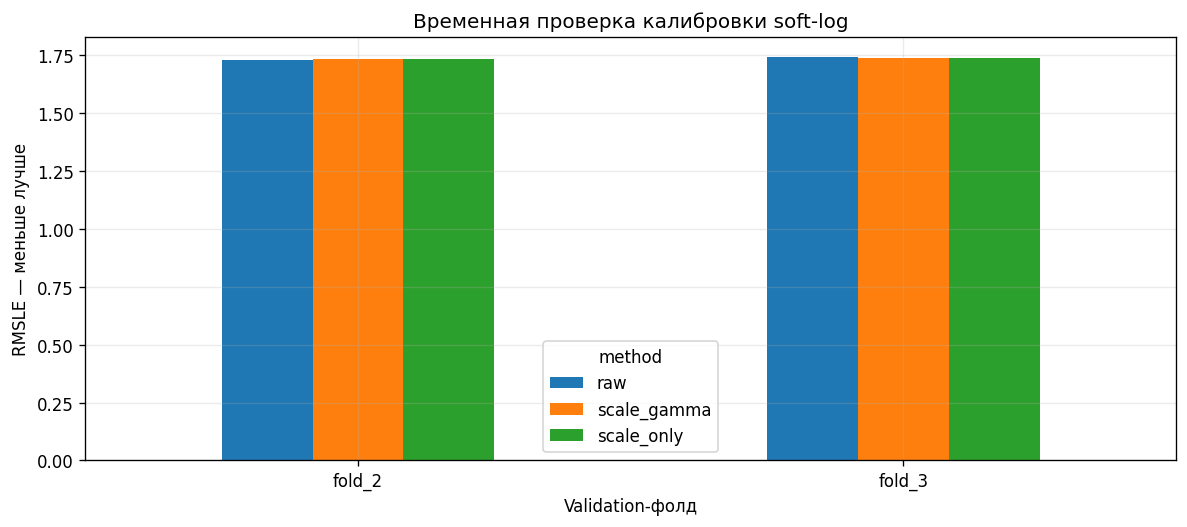

In [24]:
# Временная проверка калибровки объединения стадий.
#
# Формула:
# calibrated_log = scale * probability**gamma * predicted_positive_log
#
# Варианты:
# 1. raw: исходная формула;
# 2. scale_only: только общий множитель;
# 3. scale_gamma: множитель и степень вероятности.
#
# Параметры обучаются только на более ранних OOF-фолдах.

CALIBRATION_GAMMA_GRID = np.linspace(
    0.50,
    2.00,
    151,
)


def fit_soft_log_calibration(
    probability,
    predicted_positive_log,
    actual_log,
    gamma_grid,
):
    probability = np.asarray(
        probability,
        dtype=np.float64,
    )
    predicted_positive_log = np.asarray(
        predicted_positive_log,
        dtype=np.float64,
    )
    actual_log = np.asarray(
        actual_log,
        dtype=np.float64,
    )

    assert (
        probability.shape
        == predicted_positive_log.shape
        == actual_log.shape
    )
    assert np.isfinite(probability).all()
    assert np.isfinite(predicted_positive_log).all()
    assert np.isfinite(actual_log).all()

    best_result = None

    for gamma in gamma_grid:
        base_prediction = (
            np.power(probability, gamma)
            * predicted_positive_log
        )

        denominator = np.dot(
            base_prediction,
            base_prediction,
        )

        if denominator == 0:
            continue

        # Аналитически оптимальный scale для MSE в log-пространстве.
        scale = max(
            0.0,
            float(
                np.dot(
                    base_prediction,
                    actual_log,
                )
                / denominator
            ),
        )

        calibrated_log = scale * base_prediction

        rmsle_value = float(
            np.sqrt(
                np.mean(
                    np.square(
                        calibrated_log - actual_log
                    )
                )
            )
        )

        if (
            best_result is None
            or rmsle_value < best_result["rmsle"]
        ):
            best_result = {
                "scale": scale,
                "gamma": float(gamma),
                "rmsle": rmsle_value,
            }

    assert best_result is not None

    return best_result


# ----------------------------------------------------------------------
# Контракт функции: восстанавливаем заранее известные параметры
# ----------------------------------------------------------------------
test_probability = np.array(
    [0.15, 0.35, 0.60, 0.85],
)
test_positive_log = np.array(
    [1.0, 2.0, 3.0, 4.0],
)

test_actual_log = (
    1.20
    * np.power(test_probability, 1.30)
    * test_positive_log
)

test_calibration = fit_soft_log_calibration(
    test_probability,
    test_positive_log,
    test_actual_log,
    CALIBRATION_GAMMA_GRID,
)

np.testing.assert_allclose(
    test_calibration["gamma"],
    1.30,
    atol=1e-12,
    rtol=0.0,
)
np.testing.assert_allclose(
    test_calibration["scale"],
    1.20,
    atol=1e-10,
    rtol=0.0,
)
assert test_calibration["rmsle"] < 1e-10

print("Calibration contract: PASS")


# ----------------------------------------------------------------------
# Подготовка OOF-данных
# ----------------------------------------------------------------------
calibration_mask = (
    np.isfinite(tuned_classifier_oof_probability)
    & np.isfinite(
        tuned_regressor_oof_predicted_log
    )
)

calibration_probability = (
    tuned_classifier_oof_probability[
        calibration_mask
    ].astype(np.float64)
)
calibration_positive_log = (
    tuned_regressor_oof_predicted_log[
        calibration_mask
    ].astype(np.float64)
)
calibration_actual_gmv = y_gmv[
    calibration_mask
].astype(np.float64)
calibration_actual_log = np.log1p(
    calibration_actual_gmv
)

calibration_dates = (
    pd.to_datetime(
        cutoff_dates[calibration_mask]
    )
    .to_numpy(dtype="datetime64[D]")
)

assert len(calibration_probability) == expected_oof_rows


# ----------------------------------------------------------------------
# Честная временная проверка:
# fold_1 -> fold_2
# fold_1 + fold_2 -> fold_3
# ----------------------------------------------------------------------
calibration_records = []

for fold_name in ["fold_2", "fold_3"]:
    valid_slice = TUNING_SPLITS[
        fold_name
    ]["valid"]

    valid_date = np.datetime64(
        pd.Timestamp(
            cutoff_dates.iloc[valid_slice.start]
        ).date()
    )

    calibration_train_mask = (
        calibration_dates < valid_date
    )
    calibration_valid_mask = (
        calibration_dates == valid_date
    )

    assert calibration_train_mask.any()
    assert calibration_valid_mask.any()

    train_probability = calibration_probability[
        calibration_train_mask
    ]
    train_positive_log = calibration_positive_log[
        calibration_train_mask
    ]
    train_actual_log = calibration_actual_log[
        calibration_train_mask
    ]

    valid_probability = calibration_probability[
        calibration_valid_mask
    ]
    valid_positive_log = calibration_positive_log[
        calibration_valid_mask
    ]
    valid_actual_log = calibration_actual_log[
        calibration_valid_mask
    ]
    valid_actual_gmv = calibration_actual_gmv[
        calibration_valid_mask
    ]

    scale_only_parameters = fit_soft_log_calibration(
        train_probability,
        train_positive_log,
        train_actual_log,
        gamma_grid=np.array([1.0]),
    )

    scale_gamma_parameters = fit_soft_log_calibration(
        train_probability,
        train_positive_log,
        train_actual_log,
        gamma_grid=CALIBRATION_GAMMA_GRID,
    )

    method_parameters = {
        "raw": {
            "scale": 1.0,
            "gamma": 1.0,
        },
        "scale_only": scale_only_parameters,
        "scale_gamma": scale_gamma_parameters,
    }

    raw_prediction_log = (
        valid_probability
        * valid_positive_log
    )
    raw_rmsle = float(
        np.sqrt(
            np.mean(
                np.square(
                    raw_prediction_log
                    - valid_actual_log
                )
            )
        )
    )

    for method, parameters in method_parameters.items():
        calibrated_prediction_log = (
            parameters["scale"]
            * np.power(
                valid_probability,
                parameters["gamma"],
            )
            * valid_positive_log
        )

        calibrated_prediction = np.expm1(
            calibrated_prediction_log
        )

        method_metrics = pipeline_metrics(
            valid_actual_gmv,
            calibrated_prediction,
        )

        calibration_records.append(
            {
                "validation_fold": fold_name,
                "method": method,
                "calibration_rows": int(
                    calibration_train_mask.sum()
                ),
                "scale": parameters["scale"],
                "gamma": parameters["gamma"],
                "rmsle": method_metrics["rmsle"],
                "rmsle_improvement": (
                    raw_rmsle
                    - method_metrics["rmsle"]
                ),
                "sum_ratio": method_metrics[
                    "sum_ratio"
                ],
                "log_bias": method_metrics[
                    "log_bias"
                ],
            }
        )


temporal_calibration_results = (
    pd.DataFrame(calibration_records)
    .set_index(
        ["validation_fold", "method"]
    )
)

calibration_method_summary = (
    temporal_calibration_results
    .reset_index()
    .groupby("method", sort=False)
    .agg(
        mean_rmsle=("rmsle", "mean"),
        mean_improvement=(
            "rmsle_improvement",
            "mean",
        ),
        worst_rmsle=("rmsle", "max"),
        mean_sum_ratio=("sum_ratio", "mean"),
        mean_log_bias=("log_bias", "mean"),
    )
    .sort_values("mean_rmsle")
)

display(temporal_calibration_results)
display(calibration_method_summary)


# ----------------------------------------------------------------------
# Сравнение по временным фолдам
# ----------------------------------------------------------------------
calibration_plot_data = (
    temporal_calibration_results[
        "rmsle"
    ]
    .unstack("method")
)

ax = calibration_plot_data.plot(
    kind="bar",
    figsize=(10, 4.5),
    rot=0,
)

ax.set_title(
    "Временная проверка калибровки soft-log"
)
ax.set_xlabel("Validation-фолд")
ax.set_ylabel("RMSLE — меньше лучше")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [25]:
# Финальная калибровка обучается на всех доступных OOF-прогнозах.
# После выполнения параметры фиксируются до просмотра holdout.

FINAL_CALIBRATION_METHOD = "scale_gamma"

final_calibration_result = fit_soft_log_calibration(
    calibration_probability,
    calibration_positive_log,
    calibration_actual_log,
    gamma_grid=CALIBRATION_GAMMA_GRID,
)

FINAL_CALIBRATION_SCALE = float(
    final_calibration_result["scale"]
)
FINAL_CALIBRATION_GAMMA = float(
    final_calibration_result["gamma"]
)

# Проверяем, что optimum не упёрся в границу сетки.
assert (
    CALIBRATION_GAMMA_GRID[0]
    < FINAL_CALIBRATION_GAMMA
    < CALIBRATION_GAMMA_GRID[-1]
)

raw_oof_prediction_log = (
    calibration_probability
    * calibration_positive_log
)

calibrated_oof_prediction_log = (
    FINAL_CALIBRATION_SCALE
    * np.power(
        calibration_probability,
        FINAL_CALIBRATION_GAMMA,
    )
    * calibration_positive_log
)

raw_oof_metrics = pipeline_metrics(
    calibration_actual_gmv,
    np.expm1(raw_oof_prediction_log),
)

calibrated_oof_metrics = pipeline_metrics(
    calibration_actual_gmv,
    np.expm1(calibrated_oof_prediction_log),
)

final_calibration_summary = pd.DataFrame(
    {
        "raw": raw_oof_metrics,
        "scale_gamma": calibrated_oof_metrics,
    }
).T

final_calibration_parameters = pd.Series(
    {
        "method": FINAL_CALIBRATION_METHOD,
        "scale": FINAL_CALIBRATION_SCALE,
        "gamma": FINAL_CALIBRATION_GAMMA,
        "calibration_rows": len(
            calibration_actual_gmv
        ),
        "calibration_cutoff_max": pd.Timestamp(
            calibration_dates.max()
        ),
    },
    name="value",
).to_frame()

assert np.isfinite(
    calibrated_oof_prediction_log
).all()
assert (
    calibrated_oof_metrics["rmsle"]
    <= raw_oof_metrics["rmsle"]
)

print("Final calibration parameters: FROZEN")
display(final_calibration_parameters)
display(final_calibration_summary)

Final calibration parameters: FROZEN


,value
method,scale_gamma
scale,0.981677
gamma,1.04
calibration_rows,735683
calibration_cutoff_max,2025-12-15 00:00:00


,rmsle,sum_ratio,log_bias
raw,1.730178,0.457234,0.076690
scale_gamma,1.728269,0.411755,-0.001414


## 11. Stage 2 — Optuna для LightGBM-регрессора

Регрессор обучается только на строках с `target_nonzero == 1`. Цель обучения — `log1p(target_gmv_30d)`.

Отдельная Optuna-study минимизирует средний RMSE в логарифмическом пространстве. В свойствах trial сохраняются fold-метрики, aggregate bias, `best_iteration` и длительность.

Используется тот же набор структурных гиперпараметров, что и для классификатора, но независимое пространство поиска и независимая study. Начальный бюджет — 40 trials.

In [26]:
# Единственная финальная оценка на untouched holdout 2026-01-14.
#
# Важно:
# - параметры моделей и калибровки уже зафиксированы;
# - holdout не используется для early stopping;
# - число деревьев определяется по медиане OOF-фолдов.

FINAL_CLASSIFIER_ITERATIONS = int(
    np.median(
        tuned_classifier_best_iterations
    )
)
FINAL_REGRESSOR_ITERATIONS = int(
    np.median(
        tuned_regressor_best_iterations
    )
)

holdout_train_slice = HOLDOUT_SPLIT["train"]
holdout_valid_slice = HOLDOUT_SPLIT["valid"]

X_holdout_train = X.iloc[holdout_train_slice]
X_holdout_valid = X.iloc[holdout_valid_slice]

y_holdout_train_class = y_nonzero[
    holdout_train_slice
]
y_holdout_valid_class = y_nonzero[
    holdout_valid_slice
]

y_holdout_train_gmv = y_gmv[
    holdout_train_slice
]
y_holdout_valid_gmv = y_gmv[
    holdout_valid_slice
]

holdout_train_cutoff_max = pd.Timestamp(
    cutoff_dates.iloc[holdout_train_slice].max()
)
holdout_valid_cutoffs = pd.to_datetime(
    cutoff_dates.iloc[holdout_valid_slice]
).unique()

assert (
    holdout_train_cutoff_max
    == pd.Timestamp("2025-12-15")
)
assert len(holdout_valid_cutoffs) == 1
assert (
    pd.Timestamp(holdout_valid_cutoffs[0])
    == pd.Timestamp(HOLDOUT_DATE)
)
assert np.isfinite(y_holdout_valid_gmv).all()

print(
    "Classifier iterations:",
    FINAL_CLASSIFIER_ITERATIONS,
)
print(
    "Regressor iterations:",
    FINAL_REGRESSOR_ITERATIONS,
)
print(
    "Train rows:",
    f"{len(X_holdout_train):,}",
)
print(
    "Holdout rows:",
    f"{len(X_holdout_valid):,}",
)

holdout_training_started = perf_counter()


# ----------------------------------------------------------------------
# Стадия 1: классификатор
# ----------------------------------------------------------------------
holdout_classifier_model = lgb.LGBMClassifier(
    **classifier_best_params,
    objective="binary",
    metric="average_precision",
    n_estimators=FINAL_CLASSIFIER_ITERATIONS,
)

holdout_classifier_model.fit(
    X_holdout_train,
    y_holdout_train_class,
)

holdout_probability = (
    holdout_classifier_model.predict_proba(
        X_holdout_valid
    )[:, 1]
)


# ----------------------------------------------------------------------
# Стадия 2: регрессор на положительных наблюдениях
# ----------------------------------------------------------------------
holdout_train_positive = (
    y_holdout_train_class == 1
)

holdout_regressor_model = lgb.LGBMRegressor(
    **regressor_best_params,
    objective="regression_l2",
    metric="None",
    n_estimators=FINAL_REGRESSOR_ITERATIONS,
)

holdout_regressor_model.fit(
    X_holdout_train.loc[
        holdout_train_positive
    ],
    np.log1p(
        y_holdout_train_gmv[
            holdout_train_positive
        ]
    ),
)

holdout_predicted_positive_log = np.maximum(
    holdout_regressor_model.predict(
        X_holdout_valid
    ),
    0.0,
)

holdout_training_duration = (
    perf_counter() - holdout_training_started
)


# ----------------------------------------------------------------------
# Зафиксированное объединение стадий
# ----------------------------------------------------------------------
holdout_raw_prediction_log = (
    holdout_probability
    * holdout_predicted_positive_log
)

holdout_calibrated_prediction_log = (
    FINAL_CALIBRATION_SCALE
    * np.power(
        holdout_probability,
        FINAL_CALIBRATION_GAMMA,
    )
    * holdout_predicted_positive_log
)

holdout_raw_prediction = np.expm1(
    holdout_raw_prediction_log
)
holdout_calibrated_prediction = np.expm1(
    holdout_calibrated_prediction_log
)

assert np.isfinite(
    holdout_calibrated_prediction
).all()
assert (
    holdout_calibrated_prediction >= 0
).all()


# ----------------------------------------------------------------------
# Метрики классификатора
# ----------------------------------------------------------------------
holdout_classification_results = pd.DataFrame(
    {
        "threshold_018": classification_metrics(
            y_holdout_valid_class,
            holdout_probability,
            threshold=0.18,
        ),
        "threshold_035": classification_metrics(
            y_holdout_valid_class,
            holdout_probability,
            threshold=0.35,
        ),
        "threshold_050": classification_metrics(
            y_holdout_valid_class,
            holdout_probability,
            threshold=0.50,
        ),
    }
).T


# ----------------------------------------------------------------------
# Метрики положительного регрессора
# ----------------------------------------------------------------------
holdout_valid_positive = (
    y_holdout_valid_class == 1
)

holdout_positive_regression_results = pd.DataFrame(
    {
        "positive_regressor": (
            positive_regression_metrics(
                y_holdout_valid_gmv[
                    holdout_valid_positive
                ],
                holdout_predicted_positive_log[
                    holdout_valid_positive
                ],
            )
        )
    }
).T


# ----------------------------------------------------------------------
# Метрики полного pipeline
# ----------------------------------------------------------------------
holdout_oracle_prediction = np.where(
    holdout_valid_positive,
    np.expm1(
        holdout_predicted_positive_log
    ),
    0.0,
)

holdout_pipeline_results = pd.DataFrame(
    {
        "zero_baseline": pipeline_metrics(
            y_holdout_valid_gmv,
            np.zeros_like(
                y_holdout_valid_gmv
            ),
        ),
        "raw_soft_log": pipeline_metrics(
            y_holdout_valid_gmv,
            holdout_raw_prediction,
        ),
        "calibrated_scale_gamma": pipeline_metrics(
            y_holdout_valid_gmv,
            holdout_calibrated_prediction,
        ),
        "oracle_classifier": pipeline_metrics(
            y_holdout_valid_gmv,
            holdout_oracle_prediction,
        ),
    }
).T


# ----------------------------------------------------------------------
# Парное сравнение raw и calibrated
# ----------------------------------------------------------------------
holdout_actual_log = np.log1p(
    y_holdout_valid_gmv
)

raw_squared_error = np.square(
    holdout_raw_prediction_log
    - holdout_actual_log
)
calibrated_squared_error = np.square(
    holdout_calibrated_prediction_log
    - holdout_actual_log
)

# Положительное значение означает преимущество calibration.
paired_mse_improvement = (
    raw_squared_error
    - calibrated_squared_error
)

paired_mean = float(
    paired_mse_improvement.mean()
)
paired_standard_error = float(
    paired_mse_improvement.std(ddof=1)
    / np.sqrt(len(paired_mse_improvement))
)

holdout_calibration_comparison = pd.Series(
    {
        "raw_rmsle": holdout_pipeline_results.loc[
            "raw_soft_log",
            "rmsle",
        ],
        "calibrated_rmsle": (
            holdout_pipeline_results.loc[
                "calibrated_scale_gamma",
                "rmsle",
            ]
        ),
        "rmsle_improvement": (
            holdout_pipeline_results.loc[
                "raw_soft_log",
                "rmsle",
            ]
            - holdout_pipeline_results.loc[
                "calibrated_scale_gamma",
                "rmsle",
            ]
        ),
        "mean_mse_improvement": paired_mean,
        "mse_improvement_ci95_low": (
            paired_mean
            - 1.96 * paired_standard_error
        ),
        "mse_improvement_ci95_high": (
            paired_mean
            + 1.96 * paired_standard_error
        ),
    },
    name="value",
).to_frame()


print()
print(
    "HOLDOUT EVALUATION COMPLETE"
)
print(
    "Training duration:",
    f"{holdout_training_duration / 60:.1f} minutes",
)

display(holdout_classification_results)
display(holdout_positive_regression_results)
display(holdout_pipeline_results)
display(holdout_calibration_comparison)

Classifier iterations: 430
Regressor iterations: 1122
Train rows: 2,097,330
Holdout rows: 250,000

HOLDOUT EVALUATION COMPLETE
Training duration: 4.4 minutes


,average_precision,logloss,brier,precision,recall,f2
threshold_018,0.879349,0.471244,0.155165,0.616746,0.975948,0.874127
threshold_035,0.879349,0.471244,0.155165,0.697543,0.914704,0.861089
threshold_050,0.879349,0.471244,0.155165,0.770541,0.821204,0.810545


,rmse_log,mae_log,log_bias,sum_ratio,negative_log_prediction_share
positive_regressor,1.118807,0.88407,0.186514,0.696934,0.0


,rmsle,sum_ratio,log_bias
zero_baseline,3.203637,0.000000,-2.242099
raw_soft_log,1.685159,0.525152,0.218595
calibrated_scale_gamma,1.676222,0.472805,0.139982
oracle_classifier,0.822654,0.696934,0.100840


,value
raw_rmsle,1.685159
calibrated_rmsle,1.676222
rmsle_improvement,0.008937
mean_mse_improvement,0.030042
mse_improvement_ci95_low,0.028917
mse_improvement_ci95_high,0.031167


Holdout подтвердил модель:
- Основной calibrated RMSLE: 1.676222.
- Калибровка улучшила raw pipeline на 0.008937 (0.53%).
- Доверительный интервал улучшения MSE полностью положительный - эффект устойчив.
- При пороге 0.18: recall 0.976, F2 0.874, что соответствует приоритету на поиск ненулевых клиентов.
- Регрессор стабилен: RMSE(log)=1.119.
- Oracle RMSLE 0.823 показывает, что главный оставшийся резерв - классификация.

## 12. Диагностика положительного GMV

После настройки регрессора строятся:

- история Optuna и важность гиперпараметров;
- learning curves лучшей модели;
- `actual` против `predicted` в `log1p`-масштабе;
- остатки против прогноза и распределение остатков;
- RMSE/RMSLE по децилям положительного GMV;
- отношение сумм прогноза и факта по cutoff.

Этот блок должен показать, занижает ли регрессор крупные покупки и насколько ошибка меняется со временем.

SHAP подтверждает корректное разделение задач:
- Классификатор определяет вероятность покупки преимущественно по частоте и давности предыдущих покупок.
- Регрессор оценивает размер заказа в основном по историческому среднему GMV.
- cutoff_month_cos важен обеим стадиям т.е модель учитывает сезонность.

## 13. Выбор комбинации двух стадий

Берутся три лучших завершённых trial классификатора и три лучших trial регрессора. Девять комбинаций повторно оцениваются на тех же out-of-time фолдах.

Для каждой комбинации сравниваются:

- RMSLE-согласованная формула;
- произведение вероятности на GMV в исходном масштабе;
- пороговый challenger;
- средний RMSLE, worst-fold RMSLE и aggregate bias.

Основной критерий выбора — средний end-to-end RMSLE. При близком качестве предпочтение получает более стабильная по времени и менее смещённая связка.

## 14. Однократная оценка на финальном holdout

После фиксации гиперпараметров, калибратора, формулы объединения и диагностического threshold выбранный пайплайн один раз оценивается на cutoff `2026-01-14`.

Итоговый отчёт включает:

- метрики обеих стадий;
- общий RMSLE;
- сравнение с baseline;
- сумму фактического и прогнозного GMV;
- log-bias;
- ошибки по TP, FN, FP и TN-сегментам;
- качество по децилям GMV.

Holdout не используется для повторной настройки параметров.

## 15. SHAP-анализ финальных моделей

SHAP считается только после выбора моделей и только на репрезентативной выборке holdout размером 10–20 тысяч строк.

Для каждой стадии строятся:

- global importance bar plot;
- beeswarm;
- dependence plots для 3–5 ведущих признаков;
- waterfall для характерных ошибок.

Для классификатора объясняется raw score/log-odds. Для регрессора SHAP-интерпретация относится к `log1p(GMV)`. Локальные примеры: true positive, false negative, false positive и крупное занижение GMV.

Classifier SHAP rows: 20,000
Regressor SHAP rows: 20,000
SHAP duration: 4.5 minutes
Classifier: top features


,feature,mean_abs_shap
0,purchase_days_90d,0.693207
1,purchase_days,0.496761
2,days_since_last_purchase,0.204726
3,cutoff_month_cos,0.117006
4,recency_ratio,0.090601
5,purchased_items_total,0.081267
6,active_days_30d,0.077209
7,days_since_last_activity,0.075874
8,searches_7d,0.066899
9,purchase_days_30d,0.049880


Positive regressor: top features


,feature,mean_abs_shap
0,gmv_daily_mean,0.321091
1,whale_score,0.064073
2,gmv_total,0.060009
3,gmv_per_purchase_day,0.055637
4,gmv_90d,0.052160
5,gmv_daily_std_90d,0.046430
6,gmv_30d,0.043271
7,purchased_items_90d,0.042822
8,cutoff_month_cos,0.031450
9,searches_7d,0.028908


<TEMP>\ipykernel_16188\1663441226.py:161: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


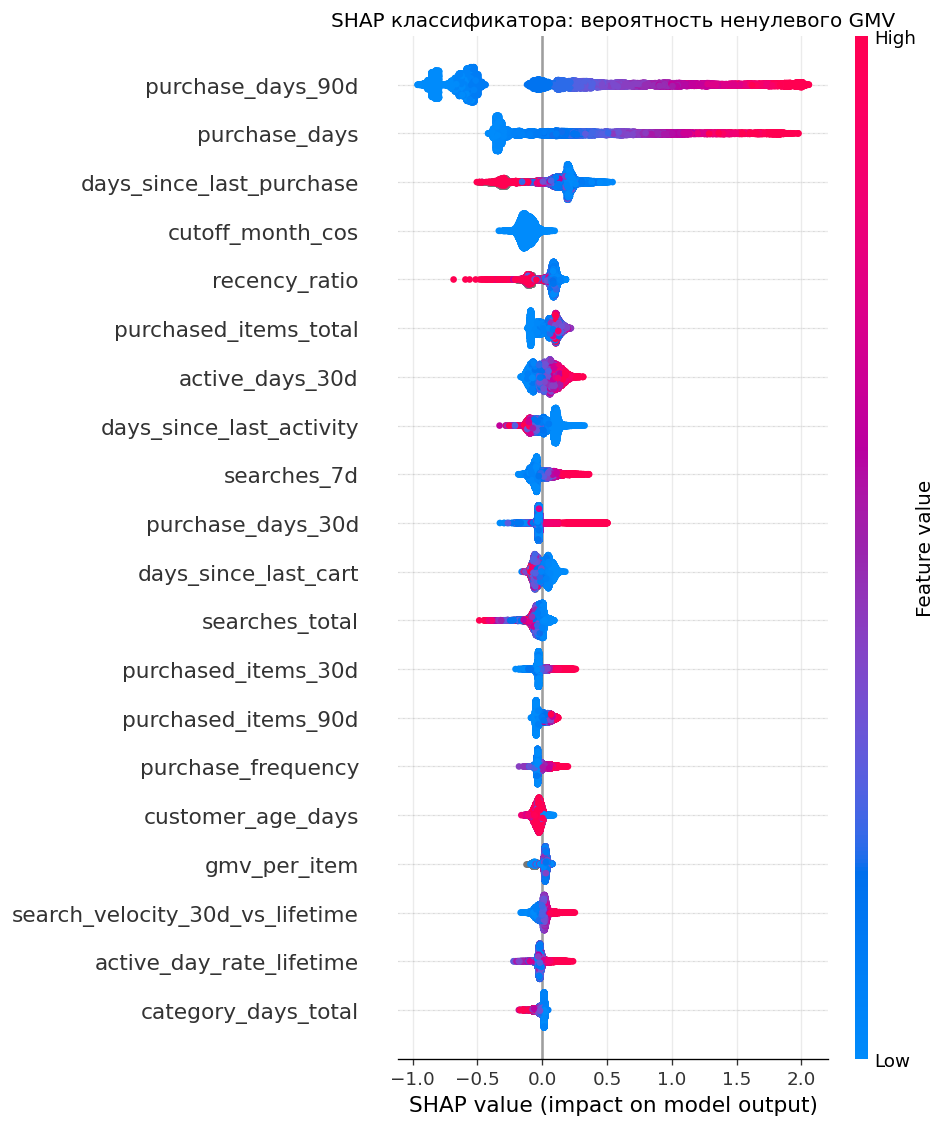

<TEMP>\ipykernel_16188\1663441226.py:177: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


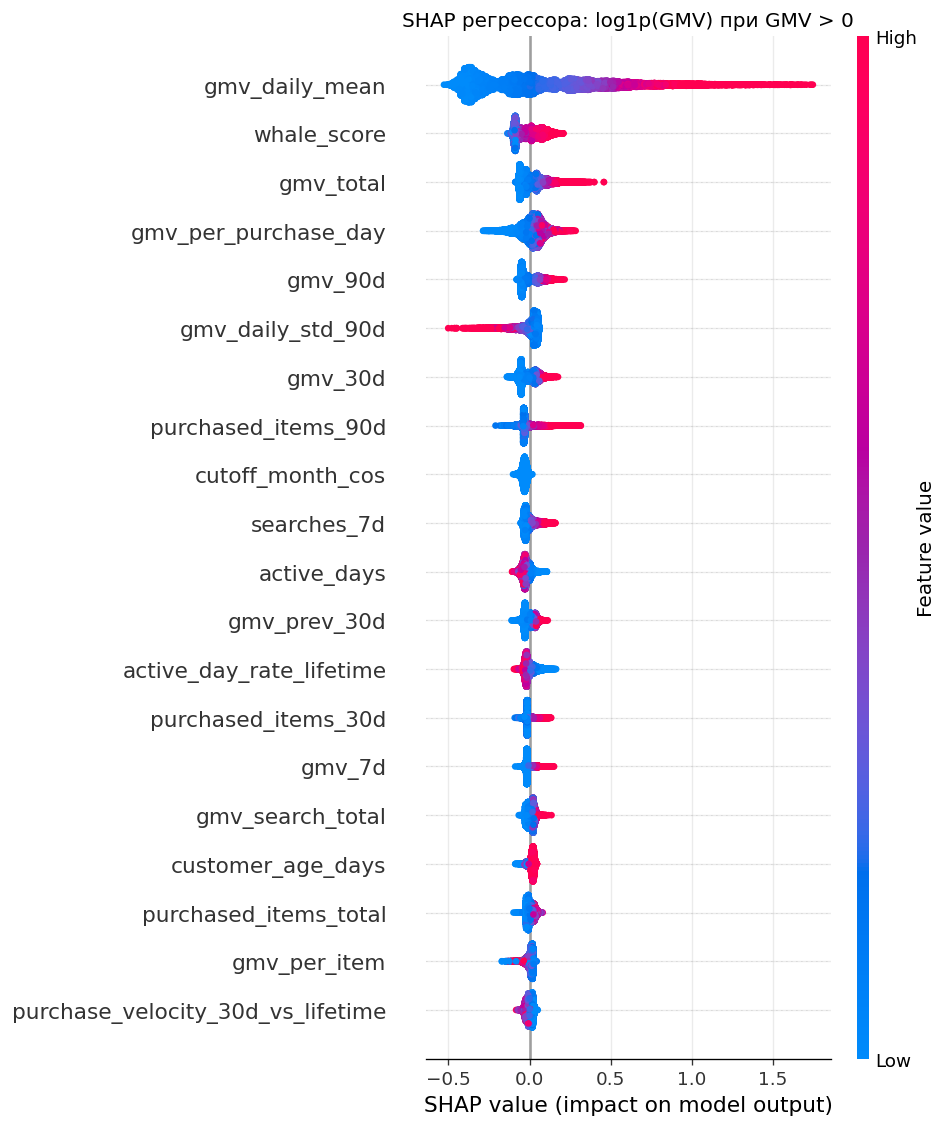

In [27]:
# SHAP-анализ двух стадий на репрезентативной выборке holdout.
#
# Классификатор объясняется в шкале raw score (log-odds).
# Регрессор объясняется в шкале предсказанного log1p(GMV).

shap_started = perf_counter()

shap_rng = np.random.default_rng(
    RANDOM_STATE
)

classifier_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_holdout_valid),
)

classifier_sample_positions = shap_rng.choice(
    len(X_holdout_valid),
    size=classifier_sample_size,
    replace=False,
)

positive_holdout_positions = np.flatnonzero(
    y_holdout_valid_class == 1
)

regressor_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(positive_holdout_positions),
)

regressor_sample_positions = shap_rng.choice(
    positive_holdout_positions,
    size=regressor_sample_size,
    replace=False,
)

X_classifier_shap = X_holdout_valid.iloc[
    classifier_sample_positions
]
X_regressor_shap = X_holdout_valid.iloc[
    regressor_sample_positions
]

print(
    "Classifier SHAP rows:",
    f"{len(X_classifier_shap):,}",
)
print(
    "Regressor SHAP rows:",
    f"{len(X_regressor_shap):,}",
)


# ----------------------------------------------------------------------
# SHAP классификатора
# ----------------------------------------------------------------------
classifier_explainer = shap.TreeExplainer(
    holdout_classifier_model
)

classifier_shap_explanation = classifier_explainer(
    X_classifier_shap,
    check_additivity=False,
)

classifier_shap_values = np.asarray(
    classifier_shap_explanation.values
)

# Защита для формата с отдельной осью классов.
if classifier_shap_values.ndim == 3:
    classifier_shap_values = (
        classifier_shap_values[:, :, 1]
    )

assert classifier_shap_values.shape == (
    len(X_classifier_shap),
    len(MODEL_FEATURE_COLUMNS),
)


# ----------------------------------------------------------------------
# SHAP положительного регрессора
# ----------------------------------------------------------------------
regressor_explainer = shap.TreeExplainer(
    holdout_regressor_model
)

regressor_shap_explanation = regressor_explainer(
    X_regressor_shap,
    check_additivity=False,
)

regressor_shap_values = np.asarray(
    regressor_shap_explanation.values
)

assert regressor_shap_values.shape == (
    len(X_regressor_shap),
    len(MODEL_FEATURE_COLUMNS),
)


# ----------------------------------------------------------------------
# Таблицы глобальной важности
# ----------------------------------------------------------------------
classifier_shap_importance = (
    pd.DataFrame(
        {
            "feature": MODEL_FEATURE_COLUMNS,
            "mean_abs_shap": np.abs(
                classifier_shap_values
            ).mean(axis=0),
        }
    )
    .sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

regressor_shap_importance = (
    pd.DataFrame(
        {
            "feature": MODEL_FEATURE_COLUMNS,
            "mean_abs_shap": np.abs(
                regressor_shap_values
            ).mean(axis=0),
        }
    )
    .sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "SHAP duration:",
    f"{(perf_counter() - shap_started) / 60:.1f} minutes",
)

print("Classifier: top features")
display(
    classifier_shap_importance.head(20)
)

print("Positive regressor: top features")
display(
    regressor_shap_importance.head(20)
)


# ----------------------------------------------------------------------
# Beeswarm: направление и величина влияния
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 8))

shap.summary_plot(
    classifier_shap_values,
    X_classifier_shap,
    max_display=20,
    show=False,
)

plt.title(
    "SHAP классификатора: вероятность ненулевого GMV"
)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))

shap.summary_plot(
    regressor_shap_values,
    X_regressor_shap,
    max_display=20,
    show=False,
)

plt.title(
    "SHAP регрессора: log1p(GMV) при GMV > 0"
)
plt.tight_layout()
plt.show()

## 16. Финальное обучение и прогноз

После завершения оценки обе модели обучаются на всех размеченных snapshot до `2026-01-14` включительно. Число boosting iterations определяется по устойчивой оценке лучших итераций временных фолдов.

Затем пайплайн формирует прогноз для snapshot `2026-02-13`, соответствующий периоду 14 февраля — 15 марта 2026 года.

Результат должен содержать `user_id`, вероятность ненулевого GMV, условный положительный прогноз и финальный GMV-прогноз. Отдельно проверяются неотрицательность, конечность значений, число пользователей и отсутствие дубликатов.

In [28]:
# Финальное обучение на всех размеченных snapshot:
# 2025-04-19 ... 2026-01-14.
#
# Прогноз строится для cutoff 2026-02-13,
# то есть для интервала 2026-02-14 ... 2026-03-15.

FINAL_TRAIN_CUTOFF_MAX = HOLDOUT_DATE

assert cutoff_dates.max().date() == FINAL_TRAIN_CUTOFF_MAX
assert len(X) == expected_labeled_rows

final_training_started = perf_counter()


# ----------------------------------------------------------------------
# Финальный классификатор
# ----------------------------------------------------------------------
final_classifier_model = lgb.LGBMClassifier(
    **classifier_best_params,
    objective="binary",
    metric="average_precision",
    n_estimators=FINAL_CLASSIFIER_ITERATIONS,
)

final_classifier_model.fit(
    X,
    y_nonzero,
)


# ----------------------------------------------------------------------
# Финальный положительный регрессор
# ----------------------------------------------------------------------
final_train_positive = y_nonzero == 1

X_final_positive = X.loc[
    final_train_positive
]
y_final_positive_log = np.log1p(
    y_gmv[final_train_positive]
)

final_regressor_model = lgb.LGBMRegressor(
    **regressor_best_params,
    objective="regression_l2",
    metric="None",
    n_estimators=FINAL_REGRESSOR_ITERATIONS,
)

final_regressor_model.fit(
    X_final_positive,
    y_final_positive_log,
)

del X_final_positive, y_final_positive_log
_ = gc.collect()


# ----------------------------------------------------------------------
# Чтение inference snapshot через PyArrow
# ----------------------------------------------------------------------
INFERENCE_FILTER = (
    ds.field("cutoff_date") == INFERENCE_DATE
)

inference_table = prepared_dataset.to_table(
    columns=[
        "user_id",
        "cutoff_date",
        *MODEL_FEATURE_COLUMNS,
    ],
    filter=INFERENCE_FILTER,
)

expected_inference_rows = int(
    cutoff_summary.loc[
        cutoff_summary["cutoff_date"].eq(
            INFERENCE_DATE
        ),
        "rows",
    ].iloc[0]
)

assert (
    inference_table.num_rows
    == expected_inference_rows
)

inference_user_ids = (
    inference_table["user_id"]
    .combine_chunks()
)
inference_cutoffs = (
    inference_table["cutoff_date"]
    .combine_chunks()
)

X_inference = (
    inference_table
    .select(list(MODEL_FEATURE_COLUMNS))
    .to_pandas(split_blocks=True)
)

del inference_table
_ = gc.collect()

assert X_inference.shape == (
    expected_inference_rows,
    len(MODEL_FEATURE_COLUMNS),
)
assert tuple(X_inference.columns) == (
    MODEL_FEATURE_COLUMNS
)

# NaN разрешены, бесконечности — нет.
for column in X_inference.select_dtypes(
    include=["floating"]
).columns:
    assert not np.isinf(
        X_inference[column].to_numpy(copy=False)
    ).any(), column

inference_user_id_values = (
    inference_user_ids.to_numpy(
        zero_copy_only=False
    )
)

assert (
    len(np.unique(inference_user_id_values))
    == expected_inference_rows
)


# ----------------------------------------------------------------------
# Предсказания двух стадий
# ----------------------------------------------------------------------
final_inference_probability = (
    final_classifier_model.predict_proba(
        X_inference
    )[:, 1]
)

final_inference_positive_log = np.maximum(
    final_regressor_model.predict(
        X_inference
    ),
    0.0,
)

final_inference_raw_log = (
    final_inference_probability
    * final_inference_positive_log
)

final_inference_calibrated_log = (
    FINAL_CALIBRATION_SCALE
    * np.power(
        final_inference_probability,
        FINAL_CALIBRATION_GAMMA,
    )
    * final_inference_positive_log
)

final_inference_prediction_gmv = np.expm1(
    final_inference_calibrated_log
)

assert np.isfinite(
    final_inference_probability
).all()
assert np.isfinite(
    final_inference_positive_log
).all()
assert np.isfinite(
    final_inference_prediction_gmv
).all()

assert (
    (final_inference_probability >= 0)
    & (final_inference_probability <= 1)
).all()
assert (
    final_inference_prediction_gmv >= 0
).all()


# ----------------------------------------------------------------------
# Контрольное резюме inference-прогнозов
# ----------------------------------------------------------------------
final_inference_summary = pd.Series(
    {
        "rows": len(X_inference),
        "classifier_iterations": (
            FINAL_CLASSIFIER_ITERATIONS
        ),
        "regressor_iterations": (
            FINAL_REGRESSOR_ITERATIONS
        ),
        "probability_mean": float(
            final_inference_probability.mean()
        ),
        "probability_median": float(
            np.median(
                final_inference_probability
            )
        ),
        "probability_ge_018_share": float(
            np.mean(
                final_inference_probability >= 0.18
            )
        ),
        "probability_ge_035_share": float(
            np.mean(
                final_inference_probability >= 0.35
            )
        ),
        "prediction_gmv_mean": float(
            final_inference_prediction_gmv.mean()
        ),
        "prediction_gmv_median": float(
            np.median(
                final_inference_prediction_gmv
            )
        ),
        "prediction_gmv_max": float(
            final_inference_prediction_gmv.max()
        ),
        "prediction_gmv_sum": float(
            final_inference_prediction_gmv.sum()
        ),
        "training_and_inference_minutes": (
            perf_counter() - final_training_started
        ) / 60,
    },
    name="value",
).to_frame()

inference_prediction_preview = pd.DataFrame(
    {
        "user_id": inference_user_id_values[:10],
        "cutoff_date": pd.to_datetime(
            inference_cutoffs.to_numpy(
                zero_copy_only=False
            )[:10]
        ),
        "nonzero_probability": (
            final_inference_probability[:10]
        ),
        "positive_log_gmv": (
            final_inference_positive_log[:10]
        ),
        "predict": (
            final_inference_prediction_gmv[:10]
        ),
    }
)

display(final_inference_summary)
display(inference_prediction_preview)

,value
rows,2.500000e+05
classifier_iterations,4.300000e+02
regressor_iterations,1.122000e+03
probability_mean,5.741789e-01
probability_median,6.010621e-01
probability_ge_018_share,8.581360e-01
probability_ge_035_share,7.125360e-01
prediction_gmv_mean,3.715323e+01
prediction_gmv_median,7.787434e+00
prediction_gmv_max,3.292313e+03


,user_id,cutoff_date,nonzero_probability,positive_log_gmv,predict
0,2,2026-02-13,0.311915,3.475943,1.761768
1,7,2026-02-13,0.943136,4.738133,78.564051
2,15,2026-02-13,0.523704,4.318356,7.700677
3,18,2026-02-13,0.981416,5.200182,148.347387
4,23,2026-02-13,0.127728,3.620366,0.519041
5,26,2026-02-13,0.111253,3.574736,0.429869
6,27,2026-02-13,0.502131,3.601336,4.623535
7,30,2026-02-13,0.218371,3.341807,0.962232
8,34,2026-02-13,0.292674,3.009089,1.277510
9,37,2026-02-13,0.436566,3.888936,4.014437


Inference выглядит корректно: 250 000 уникальных пользователей, прогнозы конечные и неотрицательные. Итоговая сумма около 9.29 млн, медиана 7.79, максимум 3292.31.

## 17. Сохранение артефактов и итоговый отчёт

После успешного запуска сохраняются только необходимые артефакты:

- две Optuna-study в SQLite для возобновления;
- финальные LightGBM-модели;
- параметры калибратора и диагностический threshold;
- OOF/holdout-метрики;
- финальный прогноз в Parquet;
- краткая таблица выбранных параметров и результатов.

Завершающая ячейка должна явно ответить: улучшен ли baseline, устойчиво ли качество по времени и присутствует ли систематическое занижение суммарного GMV.

In [30]:
# Сохранение submission и воспроизводимых артефактов.
#
# LightGBM-модели сохраняются через model_to_string() и Path.write_text(),
# поскольку нативный C API LightGBM на Windows не поддержал путь
# с кириллицей.

import json
from datetime import datetime, timezone

import pyarrow.csv as pacsv


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SUBMISSION_PATH = (
    ARTIFACT_DIR / "submission.csv"
)
CLASSIFIER_MODEL_PATH = (
    ARTIFACT_DIR / "classifier_lightgbm.txt"
)
REGRESSOR_MODEL_PATH = (
    ARTIFACT_DIR / "positive_regressor_lightgbm.txt"
)
METADATA_PATH = (
    ARTIFACT_DIR / "two_stage_metadata.json"
)


# ----------------------------------------------------------------------
# Итоговый CSV: строго user_id, predict
# ----------------------------------------------------------------------
submission_table = pyarrow.table(
    {
        "user_id": inference_user_ids,
        "predict": pyarrow.array(
            final_inference_prediction_gmv,
            type=pyarrow.float64(),
        ),
    }
)

assert submission_table.num_rows == 250_000
assert submission_table.column_names == [
    "user_id",
    "predict",
]

pacsv.write_csv(
    submission_table,
    SUBMISSION_PATH,
    write_options=pacsv.WriteOptions(
        include_header=True,
        delimiter=",",
    ),
)


# ----------------------------------------------------------------------
# LightGBM-модели
# ----------------------------------------------------------------------
# Python Path корректно работает с Unicode-путями Windows.
CLASSIFIER_MODEL_PATH.write_text(
    final_classifier_model.booster_.model_to_string(),
    encoding="utf-8",
)

REGRESSOR_MODEL_PATH.write_text(
    final_regressor_model.booster_.model_to_string(),
    encoding="utf-8",
)

assert CLASSIFIER_MODEL_PATH.is_file()
assert REGRESSOR_MODEL_PATH.is_file()
assert CLASSIFIER_MODEL_PATH.stat().st_size > 0
assert REGRESSOR_MODEL_PATH.stat().st_size > 0


# ----------------------------------------------------------------------
# JSON-сериализация метаданных
# ----------------------------------------------------------------------
def json_default(value):
    if isinstance(value, np.generic):
        return value.item()

    if isinstance(
        value,
        (date, datetime, Path),
    ):
        return str(value)

    raise TypeError(
        f"Object of type {type(value)} "
        "is not JSON serializable"
    )


model_metadata = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "dataset": str(DATA_PATH),
    "training_cutoff_max": str(
        FINAL_TRAIN_CUTOFF_MAX
    ),
    "inference_cutoff": str(
        INFERENCE_DATE
    ),
    "forecast_start": str(
        FORECAST_START
    ),
    "forecast_end": str(
        FORECAST_END
    ),
    "submission": {
        "path": str(SUBMISSION_PATH),
        "columns": [
            "user_id",
            "predict",
        ],
        "rows": 250_000,
        "target": "target_gmv_30d",
    },
    "features": {
        "count": len(
            MODEL_FEATURE_COLUMNS
        ),
        "columns": list(
            MODEL_FEATURE_COLUMNS
        ),
        "dropped": list(
            DROPPED_FEATURES
        ),
    },
    "classifier": {
        "iterations": (
            FINAL_CLASSIFIER_ITERATIONS
        ),
        "parameters": (
            classifier_best_params
        ),
        "report_threshold": (
            CLASSIFIER_REPORT_THRESHOLD
        ),
    },
    "positive_regressor": {
        "iterations": (
            FINAL_REGRESSOR_ITERATIONS
        ),
        "parameters": (
            regressor_best_params
        ),
        "target_transform": (
            "log1p(target_gmv_30d)"
        ),
    },
    "combination": {
        "method": (
            FINAL_CALIBRATION_METHOD
        ),
        "formula": (
            "expm1(scale * probability**gamma "
            "* predicted_positive_log)"
        ),
        "scale": (
            FINAL_CALIBRATION_SCALE
        ),
        "gamma": (
            FINAL_CALIBRATION_GAMMA
        ),
    },
    "holdout": {
        "cutoff": str(
            HOLDOUT_DATE
        ),
        "average_precision": float(
            holdout_classification_results.loc[
                "threshold_018",
                "average_precision",
            ]
        ),
        "recall_at_018": float(
            holdout_classification_results.loc[
                "threshold_018",
                "recall",
            ]
        ),
        "f2_at_018": float(
            holdout_classification_results.loc[
                "threshold_018",
                "f2",
            ]
        ),
        "raw_rmsle": float(
            holdout_pipeline_results.loc[
                "raw_soft_log",
                "rmsle",
            ]
        ),
        "calibrated_rmsle": float(
            holdout_pipeline_results.loc[
                "calibrated_scale_gamma",
                "rmsle",
            ]
        ),
    },
    "inference_prediction": {
        "mean": float(
            final_inference_prediction_gmv.mean()
        ),
        "median": float(
            np.median(
                final_inference_prediction_gmv
            )
        ),
        "maximum": float(
            final_inference_prediction_gmv.max()
        ),
        "sum": float(
            final_inference_prediction_gmv.sum()
        ),
    },
}

with METADATA_PATH.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        ensure_ascii=False,
        indent=2,
        default=json_default,
    )

assert METADATA_PATH.is_file()
assert METADATA_PATH.stat().st_size > 0


# ----------------------------------------------------------------------
# Проверка записанного CSV
# ----------------------------------------------------------------------
submission_check = pacsv.read_csv(
    SUBMISSION_PATH,
    convert_options=pacsv.ConvertOptions(
        column_types={
            "user_id": pyarrow.int64(),
            "predict": pyarrow.float64(),
        }
    ),
)

assert submission_check.num_rows == 250_000
assert submission_check.column_names == [
    "user_id",
    "predict",
]

written_user_ids = (
    submission_check["user_id"]
    .combine_chunks()
    .to_numpy(zero_copy_only=False)
)

written_predictions = (
    submission_check["predict"]
    .combine_chunks()
    .to_numpy(zero_copy_only=False)
)

assert np.array_equal(
    written_user_ids,
    inference_user_id_values,
)
assert len(
    np.unique(written_user_ids)
) == 250_000

assert np.isfinite(
    written_predictions
).all()
assert (
    written_predictions >= 0
).all()

np.testing.assert_allclose(
    written_predictions,
    final_inference_prediction_gmv,
    rtol=1e-12,
    atol=1e-12,
)


# ----------------------------------------------------------------------
# Проверка сохранённых LightGBM-моделей
# ----------------------------------------------------------------------
# Загружаем из строки, чтобы снова не передавать Unicode-путь
# в нативный C API LightGBM.
reloaded_classifier = lgb.Booster(
    model_str=(
        CLASSIFIER_MODEL_PATH.read_text(
            encoding="utf-8",
        )
    )
)

reloaded_regressor = lgb.Booster(
    model_str=(
        REGRESSOR_MODEL_PATH.read_text(
            encoding="utf-8",
        )
    )
)

verification_rows = min(
    1_000,
    len(X_inference),
)

X_verification = X_inference.iloc[
    :verification_rows
]

reloaded_probability = (
    reloaded_classifier.predict(
        X_verification
    )
)

reloaded_positive_log = np.maximum(
    reloaded_regressor.predict(
        X_verification
    ),
    0.0,
)

np.testing.assert_allclose(
    reloaded_probability,
    final_inference_probability[
        :verification_rows
    ],
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    reloaded_positive_log,
    final_inference_positive_log[
        :verification_rows
    ],
    rtol=1e-12,
    atol=1e-12,
)


# ----------------------------------------------------------------------
# Проверка JSON-метаданных
# ----------------------------------------------------------------------
with METADATA_PATH.open(
    "r",
    encoding="utf-8",
) as metadata_file:
    metadata_check = json.load(
        metadata_file
    )

assert (
    metadata_check["submission"]["rows"]
    == 250_000
)
assert (
    metadata_check["submission"]["columns"]
    == ["user_id", "predict"]
)
assert (
    metadata_check["features"]["count"]
    == len(MODEL_FEATURE_COLUMNS)
)


# ----------------------------------------------------------------------
# Итоговая сводка
# ----------------------------------------------------------------------
artifact_summary = pd.DataFrame(
    [
        {
            "artifact": path.name,
            "path": str(path),
            "size_mb": (
                path.stat().st_size
                / 1024**2
            ),
        }
        for path in [
            SUBMISSION_PATH,
            CLASSIFIER_MODEL_PATH,
            REGRESSOR_MODEL_PATH,
            METADATA_PATH,
        ]
    ]
).set_index("artifact")

print("Artifact verification: PASS")

display(artifact_summary)

display(
    submission_check
    .slice(0, 10)
    .to_pandas()
)

Artifact verification: PASS


,path,size_mb
artifact,,
submission.csv,\OneDrive\Документы\Мои документ...,6.061891
classifier_lightgbm.txt,\OneDrive\Документы\Мои документ...,8.044127
positive_regressor_lightgbm.txt,\OneDrive\Документы\Мои документ...,13.568382
two_stage_metadata.json,\OneDrive\Документы\Мои документ...,0.005084


,user_id,predict
0,2,1.761768
1,7,78.564051
2,15,7.700677
3,18,148.347387
4,23,0.519041
5,26,0.429869
6,27,4.623535
7,30,0.962232
8,34,1.277510
9,37,4.014437


In [31]:
# Единый joblib-bundle первой версии модели.
#
# Содержит обе обученные модели, порядок признаков,
# калибровку и параметры инференса. Переобучение
# для последующего использования не требуется.

import joblib


MODEL_VERSION = "v1"

JOBLIB_MODEL_PATH = (
    ARTIFACT_DIR
    / f"two_stage_model_{MODEL_VERSION}.joblib"
)


two_stage_model_bundle = {
    # Версия самой модели.
    "model_version": MODEL_VERSION,

    # Версия внутренней структуры joblib-bundle.
    "format_version": 1,

    "classifier": final_classifier_model,
    "positive_regressor": final_regressor_model,

    "feature_columns": tuple(
        MODEL_FEATURE_COLUMNS
    ),
    "dropped_features": tuple(
        DROPPED_FEATURES
    ),

    "calibration": {
        "method": FINAL_CALIBRATION_METHOD,
        "scale": FINAL_CALIBRATION_SCALE,
        "gamma": FINAL_CALIBRATION_GAMMA,
    },

    "classification_thresholds": {
        "maximum_f2": 0.18,
        "recall_at_least_090": 0.35,
    },

    "target": "target_gmv_30d",
    "target_transform": "log1p",

    "training_cutoff_max": str(
        FINAL_TRAIN_CUTOFF_MAX
    ),
    "inference_cutoff": str(
        INFERENCE_DATE
    ),
    "forecast_start": str(
        FORECAST_START
    ),
    "forecast_end": str(
        FORECAST_END
    ),

    "versions": {
        "python": sys.version.split()[0],
        "lightgbm": lgb.__version__,
        "joblib": joblib.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}


# ----------------------------------------------------------------------
# Сохранение bundle
# ----------------------------------------------------------------------
joblib.dump(
    two_stage_model_bundle,
    JOBLIB_MODEL_PATH,
    compress=3,
)

assert JOBLIB_MODEL_PATH.is_file()
assert JOBLIB_MODEL_PATH.stat().st_size > 0


# ----------------------------------------------------------------------
# Проверка загрузки без переобучения
# ----------------------------------------------------------------------
loaded_model_bundle = joblib.load(
    JOBLIB_MODEL_PATH
)

assert (
    loaded_model_bundle["model_version"]
    == MODEL_VERSION
)
assert (
    loaded_model_bundle["format_version"]
    == 1
)

assert tuple(
    loaded_model_bundle["feature_columns"]
) == tuple(MODEL_FEATURE_COLUMNS)


# ----------------------------------------------------------------------
# Воспроизведение прогнозов на первых 1 000 строках
# ----------------------------------------------------------------------
joblib_verification_rows = min(
    1_000,
    len(X_inference),
)

X_joblib_verification = X_inference.loc[
    :,
    loaded_model_bundle["feature_columns"],
].iloc[:joblib_verification_rows]

loaded_probability = (
    loaded_model_bundle["classifier"]
    .predict_proba(
        X_joblib_verification
    )[:, 1]
)

loaded_positive_log = np.maximum(
    loaded_model_bundle[
        "positive_regressor"
    ].predict(
        X_joblib_verification
    ),
    0.0,
)

loaded_scale = loaded_model_bundle[
    "calibration"
]["scale"]

loaded_gamma = loaded_model_bundle[
    "calibration"
]["gamma"]

loaded_prediction = np.expm1(
    loaded_scale
    * np.power(
        loaded_probability,
        loaded_gamma,
    )
    * loaded_positive_log
)


# ----------------------------------------------------------------------
# Сравнение с исходными прогнозами
# ----------------------------------------------------------------------
np.testing.assert_allclose(
    loaded_probability,
    final_inference_probability[
        :joblib_verification_rows
    ],
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    loaded_positive_log,
    final_inference_positive_log[
        :joblib_verification_rows
    ],
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    loaded_prediction,
    final_inference_prediction_gmv[
        :joblib_verification_rows
    ],
    rtol=1e-12,
    atol=1e-12,
)


# ----------------------------------------------------------------------
# Обновление JSON-метаданных
# ----------------------------------------------------------------------
model_metadata["model_version"] = (
    MODEL_VERSION
)

model_metadata["joblib_bundle"] = {
    "model_version": MODEL_VERSION,
    "format_version": 1,
    "path": str(JOBLIB_MODEL_PATH),
    "size_mb": (
        JOBLIB_MODEL_PATH.stat().st_size
        / 1024**2
    ),
}

with METADATA_PATH.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        ensure_ascii=False,
        indent=2,
        default=json_default,
    )


# ----------------------------------------------------------------------
# Итоговая сводка
# ----------------------------------------------------------------------
joblib_summary = pd.Series(
    {
        "model_version": MODEL_VERSION,
        "format_version": 1,
        "path": str(JOBLIB_MODEL_PATH),
        "size_mb": (
            JOBLIB_MODEL_PATH.stat().st_size
            / 1024**2
        ),
        "models": 2,
        "features": len(
            loaded_model_bundle[
                "feature_columns"
            ]
        ),
        "verified_rows": (
            joblib_verification_rows
        ),
    },
    name="value",
).to_frame()

print(
    f"Joblib model {MODEL_VERSION} "
    "verification: PASS"
)

display(joblib_summary)

Joblib model v1 verification: PASS


,value
model_version,v1
format_version,1
path,\OneDrive\Документы\Мои документ...
size_mb,8.703927
models,2
features,90
verified_rows,1000
